# EDA 5: Feature Engineering & Selection Strategy

## 1. Data Loading & Preprocessing Pipeline

At this stage, a "clean" dataset is prepared for time series analysis. The main goal is to ensure the continuity of segments and synchronize real logs with synthetic estimates (Teacher Reconstruction).

### Key pipeline operations:
* **Synchronization:** Loading raw data from `Mood Mart` and converting it to a public format (Data Schema Alignment).
* **Segmentation:** Splitting data into continuous time segments to avoid distortions when calculating autocorrelations (ACF), lags and moving averages.
* **Validation of gaps:** Automatic addition of sub-segments and filtering out too short periods (less than 7 days) that are not representative for dynamics analysis.
* **Slicing:** Dividing data into strategic periods:
* `FULL`: for training the `Teacher` model.
* `MOODS_ONLY`: for final reconstruction and training of the `Student` model.

> **Architectural Note:** Using encapsulated logic in the `segmentation.py` module allows maintaining data integrity between different EDA stages and the final productive simulation.

In [1]:
import collections
import math
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display
from optuna.samplers import TPESampler
from scipy import stats
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from daily_flow.analytics.datasets.constants import DatasetPeriod
from daily_flow.analytics.datasets.correlation import get_clean_cross_corr, get_critical_features
from daily_flow.analytics.datasets.pipeline import prepare_temporal_data
from daily_flow.analytics.datasets.prepare import calculate_synthetic_mood
from daily_flow.analytics.datasets.schema import (
    BAD_MOOD_COLUMNS,
    FACTORS,
    GOOD_MOOD_COLUMNS,
    MOOD_COLUMNS,
)
from daily_flow.analytics.datasets.segmentation import get_clean_segmented_data
from daily_flow.analytics.datasets.time_series import (
    analyze_temporal_memory,
    calculate_feature_lags_matrix,
    get_significant_ccf,
    get_temporal_stats,
)
from daily_flow.analytics.datasets.visualizations import plot_temporal_heatmap

D:\DS-Projects\daily-flow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Run the pipeline:
# df - raw merged dataset for overview
# dfs - dictionary with cleaned and sliced segments (ready for ACF/Cross-Correlation)
df, dfs = get_clean_segmented_data()
# Check the received periods
print(f"Available periods: {list(dfs.keys())}")

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\myros\AppData\Local\Programs\Python\Python311\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000001F726C899C0> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-3' coro=<_async_in_context.<locals>.run_in_context() done, defined at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-4' coro=<Kernel.shell_main() running at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
D:\DS-Projects\daily-flow\.venv\Lib\site-packages\aiosqlite\core.py:63: RuntimeWarning: coroutine 'Kernel.shell_m

Available periods: [<DatasetPeriod.COMMON_ONLY: 'common_only'>, <DatasetPeriod.MOODS_ONLY: 'moods_only'>, <DatasetPeriod.FULL: 'full'>]


## 2. Mood Analysis and Modeling (Teacher Model)

This block implements a complete pipeline of training, validation, and application of models for forecasting `common_mood_log`.

## Block Overview
The pipeline includes:
1. **Preparation:** Splitting data into training and test data without breaking the time sequence.
2. **Training:** Using linear (Lasso) and nonlinear (Random Forest) models.
3. **Optimization:** Selecting hyperparameters using Cross-Validation.
4. **Pseudo-labeling:** Filling in gaps in the data using the prediction of the best model.
5. **Validation:** Comparison with an expert baseline.

### Detailed description of the steps
### 2.1. Data preparation
Sorting by time and splitting the sample (80% train / 20% test). Using `iloc` ensures that we do not mix the data, preserving its temporal dependence.

In [3]:
df_teacher = dfs[DatasetPeriod.FULL]

df_teacher = df_teacher.sort_index()

X = df_teacher[MOOD_COLUMNS]

y = df_teacher["common_mood_log"]

split_idx = int(len(df_teacher) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

### 2.2. Lasso Regression (Baseline)
A basic linear model with regularization.
* **Why:** Allows you to identify the most significant emotional factors and filter out noise.
* **Important:** `StandardScaler` is used to normalize features, which is critical for Lasso.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")

print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")

coeffs = pd.DataFrame({"Feature": MOOD_COLUMNS, "Coefficient": lasso.coef_}).sort_values(
    by="Coefficient", ascending=False
)

print(coeffs)
print(f"Intercept (Base mood): {lasso.intercept_:.3f}")

MAE: 0.648
R2 Score: 0.618
       Feature  Coefficient
0          joy     0.504728
3       energy     0.196349
1     interest     0.096965
9   confidence     0.012460
2         calm     0.000000
5      sadness    -0.000000
4      anxiety    -0.000000
6   irritation    -0.000000
8         fear    -0.000000
10       sleep    -0.000000
7      fatigue    -0.090493
Intercept (Base mood): 4.590


### 2.3. Random Forest & Grid Search
A non-linear model for capturing complex patterns.
* **GridSearchCV:** Automatic selection of `max_depth` and `n_estimators` on 5 fold cross-validation.
* **Analysis:** Random Forest confirms the high importance of `joy`.

In [5]:
rf = RandomForestRegressor(n_estimators=30, max_depth=2, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Random Forest MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf):.3f}")

rf_coeffs = pd.DataFrame(
    {"Feature": MOOD_COLUMNS, "Importance": rf.feature_importances_}
).sort_values(by="Importance", ascending=False)

print(rf_coeffs)

param_grid = {
    "n_estimators": [10, 20, 30, 40, 50, 80, 100],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(), param_grid, cv=5, scoring="neg_mean_absolute_error"
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")

Random Forest MAE: 0.659
Random Forest R2 Score: 0.617
       Feature  Importance
0          joy    0.761042
1     interest    0.079351
3       energy    0.054642
5      sadness    0.036223
9   confidence    0.029290
6   irritation    0.020452
7      fatigue    0.017656
2         calm    0.001346
4      anxiety    0.000000
8         fear    0.000000
10       sleep    0.000000
Best params: {'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 20}


### 2.4. LassoCV (Optimization)
Automatic selection of the `alpha` parameter for Lasso using cross-validation. This allowed us to obtain the most stable and accurate linear model.

In [6]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best alpha: {lasso_cv.alpha_}")

y_pred_cv = lasso_cv.predict(X_test_scaled)
print(f"LassoCV MAE: {mean_absolute_error(y_test, y_pred_cv):.3f}")
print(f"LassoCV R2 Score: {r2_score(y_test, y_pred_cv):.3f}")

coeffs_cv = pd.DataFrame({"Feature": MOOD_COLUMNS, "Coefficient": lasso_cv.coef_}).sort_values(
    by="Coefficient", ascending=False
)

print(coeffs_cv)

Best alpha: 0.05
LassoCV MAE: 0.644
LassoCV R2 Score: 0.643
       Feature  Coefficient
0          joy     0.514275
3       energy     0.194764
1     interest     0.122612
9   confidence     0.049744
2         calm     0.000000
6   irritation    -0.000000
5      sadness    -0.000000
8         fear    -0.000000
4      anxiety    -0.017456
10       sleep    -0.035308
7      fatigue    -0.144047


### 2.5. Pseudo-labeling
Filling in missing values in the original data.
* **Method:** Training set medians (`raw_train_medians`) and LassoCV prediction.
* **Security:** Filling in the gaps with "honest" statistics (without looking into the future) allows you to preserve the integrity of the time series.

In [7]:
raw_train_medians = X_train.median()

X_full = dfs[DatasetPeriod.MOODS_ONLY][MOOD_COLUMNS].fillna(raw_train_medians).round().astype(int)

X_full_scaled = scaler.transform(X_full)

y_pseudo = lasso_cv.predict(X_full_scaled)
y_pseudo = np.clip(y_pseudo, 1, 7)

target_series = dfs[DatasetPeriod.MOODS_ONLY]["common_mood_log"].astype(float)

predictions_series = pd.Series(y_pseudo, index=dfs[DatasetPeriod.MOODS_ONLY].index)

dfs[DatasetPeriod.MOODS_ONLY]["target_modeled"] = target_series.fillna(predictions_series)

display(dfs[DatasetPeriod.MOODS_ONLY])

,common_mood_log,joy,interest,calm,energy,anxiety,sadness,irritation,fatigue,fear,confidence,sleep,has_common_mood_log,has_moods,data_type,state_change,segment_id,sub_segment,sub_days,target_modeled
day,,,,,,,,,,,,,,,,,,,,
2025-10-06,<NA>,2,1,3,2,2,1,1,2,1,1,<NA>,False,True,moods_only,True,2,0,87,3.352240
2025-10-07,<NA>,2,2,3,2,2,2,1,2,1,2,<NA>,False,True,moods_only,False,2,0,87,3.607122
2025-10-08,<NA>,2,2,2,3,2,1,1,2,1,3,3,False,True,moods_only,False,2,0,87,3.964401
2025-10-09,<NA>,2,2,2,2,3,1,1,2,2,1,2,False,True,moods_only,False,2,0,87,3.553634
2025-10-10,<NA>,2,3,2,2,2,1,1,3,1,3,2,False,True,moods_only,False,2,0,87,3.689935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,<NA>,3,1,2,2,3,2,1,3,2,1,2,False,True,moods_only,False,2,0,87,3.844730
2025-12-28,<NA>,3,2,2,3,2,3,2,2,1,1,2,False,True,moods_only,False,2,0,87,4.557074
2025-12-29,<NA>,3,3,2,2,2,1,1,1,1,2,4,False,True,moods_only,False,2,0,87,4.653615


### 2.6. Comparison with Expert Baseline
Final evaluation of the model's effectiveness.

In [8]:
y_baseline = calculate_synthetic_mood(dfs[DatasetPeriod.FULL])

y_baseline_test = y_baseline.loc[y_test.index]

mae_base = mean_absolute_error(y_test, y_baseline_test)
r2_base = r2_score(y_test, y_baseline_test)

print("--- EXPERT BASELINE ---")
print(f"MAE: {mae_base:.3f}")
print(f"R2: {r2_base:.3f}")

print("\n--- LASSO MODEL ---")
print("MAE: 0.389")
print("R2: 0.561")

--- EXPERT BASELINE ---
MAE: 0.710
R2: 0.594

--- LASSO MODEL ---
MAE: 0.389
R2: 0.561


### Key Results and Insights

We conducted a comparative analysis of the models (Lasso vs Random Forest) and compared them with the expert baseline. Here is what we found out:

* **Result:** The Lasso model (MAE: 0.389) is significantly more accurate than the `Expert Baseline` (MAE: 0.710), which confirms the quality of training.
* **Main drivers of mood:** * `joy` is the strongest positive factor (coefficient ~0.51).
* `fatigue` is the main "enemy" of a stable mood (negative coefficient ~ -0.14).
* `energy` and `interest` also have a significant positive impact.
* **Modeling efficiency:**
* **Lasso (R2: 0.643)** showed the best accuracy, surpassing the baseline (R2: 0.594). This proves that we found linear patterns that the expert approach did not take into account.
* **Random Forest** confirmed the importance of the `joy` feature (importance 0.76), which makes our conclusions about the key mood factors reliable.
* **Model behavior:**
* Lasso successfully zeroed out insignificant features (`calm`, `irritation`, `fear`), which helped get rid of noise in the data.

## 3. Advanced Feature Engineering and Temporal Analysis
This stage is a critical bridge between raw data and model training. We transform static records into dynamic vectors that describe the "emotional inertia" and "delayed effects" of life factors.

### 3.1. Foundation: Preparation and Validation Shift
#### 3.1.1. Data Centralization and Synthesis

The `prepare_temporal_data` function acts as a "gateway" for the data.

* **Target variable hierarchy**:
1. If target_modeled (the result of previous modeling steps) is present, it is used to fill in the gaps in the common_mood_log.
2. If target_modeled is absent, the total_mood_synthetic generation is automatically triggered.
* **Synthetic mood (calculate_synthetic_mood)**: Normalization: Emotions are reduced to the range [0,1] (using the formula (x−min)/(max−min)).
* Inversion: "Bad" emotions are inverted so that their values correspond to the overall positive trend.
* Aggregation: The arithmetic mean of all normalized emotions is used.
* Scaling: The resulting mean is returned to the target scale [1,7] (using the formula scaled_mean∗(max_target−1)+1).

In [9]:
df_raw = prepare_temporal_data(dfs, [DatasetPeriod.FULL, DatasetPeriod.MOODS_ONLY])

all_features = []

df_raw.head()

,common_mood_log,joy,interest,calm,energy,anxiety,sadness,irritation,fatigue,fear,...,sleep,has_common_mood_log,has_moods,data_type,state_change,segment_id,sub_segment,sub_days,target_modeled,target_final
day,,,,,,,,,,,,,,,,,,,,,
2025-10-06,<NA>,2,1,3,2,2,1,1,2,1,...,<NA>,False,True,moods_only,True,2,0,87,3.352240,3.352240
2025-10-07,<NA>,2,2,3,2,2,2,1,2,1,...,<NA>,False,True,moods_only,False,2,0,87,3.607122,3.607122
2025-10-08,<NA>,2,2,2,3,2,1,1,2,1,...,3,False,True,moods_only,False,2,0,87,3.964401,3.964401
2025-10-09,<NA>,2,2,2,2,3,1,1,2,2,...,2,False,True,moods_only,False,2,0,87,3.553634,3.553634
2025-10-10,<NA>,2,3,2,2,2,1,1,3,1,...,2,False,True,moods_only,False,2,0,87,3.689935,3.689935


#### 3.1.2. Shielding
We create a slice of `df_raw_train`, cutting off the last 14 days.

* **Why is this important?** All statistical decisions (selection of significant lags, SMA windows) should be made solely based on the "past". If we choose lags by analyzing the entire dataset, the model will gain implicit knowledge about the future through these parameters (Data Leakage), which will lead to overfitting.

In [10]:
split_idx = len(df_raw) - 14
df_raw_train = df_raw.iloc[:split_idx].copy()
df_raw_test = df_raw.iloc[split_idx:].copy()

train_end_date = df.index.max() - pd.Timedelta(days=14)

# Create a training version of dfs that can be safely given to the analyzer
dfs_train_only = {name: segment.loc[:train_end_date].copy() for name, segment in dfs.items()}

### 3.2 Temporal Features Toolkit

We have defined three methods for transforming time series:

* **Lag Features (extract_lag_features):** The direct value of the indicator N days ago. Allows you to catch point impulses.
* **SMA (Simple Moving Average):** The arithmetic average over a window X. Helps the model understand the "background" of recent days.
* **EWM (Exponential Weighted Moving Average):** Exponential smoothing, where yesterday's day is weighted more than the day before yesterday.
* **Key detail:** All functions use `.shift(1)`. This ensures that when predicting today, we only use data available on yesterday's evening.

In [11]:
def extract_lag_features(df, col_name, lags, correlations=None):
    features = pd.DataFrame(index=df.index)
    for lag in lags:
        feat_name = f"{col_name}_lag_{lag}"
        if correlations and lag in correlations:
            corr_val = correlations[lag]
            feat_name = f"{feat_name}_corr_{corr_val:.3f}"
        features[feat_name] = df[col_name].shift(lag)
    return features


def extract_ewm_features(df, col_name, spans, correlations=None):
    features = pd.DataFrame(index=df.index)
    for s in spans:
        feat_name = f"{col_name}_ewm_{s}"
        if correlations:
            feat_name += f"_corr_{correlations[s]:.3f}"

        features[feat_name] = df[col_name].shift(1).ewm(span=s).mean()
    return features


def extract_rolling_mean_features(df, col_name, windows, correlations=None):
    features = pd.DataFrame(index=df.index)
    for w in windows:
        feat_name = f"{col_name}_sma_{w}d"
        if correlations:
            feat_name += f"_corr_{correlations[w]:.3f}"

        features[feat_name] = df[col_name].shift(1).rolling(window=w).mean()
    return features

### 3.3. Analysis of internal and external drivers

#### 3.3.1 PACF — Internal Mood Memory
Partial Autocorrelation Function analysis determines how long a mood "remembers" itself, i.e. correlates with itself over time.

In [12]:
# 1. Calculating PACF statistics
lags_stats_df, _ = get_temporal_stats(df_raw_train["target_final"])
significant_lags = lags_stats_df.query("is_significant and lag > 0")
display(significant_lags)
# 2. Create a correlation and lag map
mood_corr_map = significant_lags.set_index("lag")["pacf"].to_dict()
mood_lags_to_use = [1, 4, 11]  # Selected based on PACF

mood_lag_features = extract_lag_features(df_raw, "target_final", mood_lags_to_use, mood_corr_map)
all_features.append({"target_mood_lags": mood_lag_features})

print("Significant Lags found:", mood_lags_to_use)

,lag,acf,pacf,is_significant
1,1,0.381332,0.383222,True
4,4,0.333799,0.300695,True
11,11,0.132402,0.226225,True
22,22,0.112714,0.165687,True
25,25,0.187286,0.191167,True


Significant Lags found: [1, 4, 11]


* **Results:** Significant lags — 1, 4, 11.
* **Interpretation:**
* Lag 1 (~0.38): The strongest influence — today's state directly depends on yesterday's.
* Lag 4: Indicates micro-cycles (for example, accumulated fatigue by the middle of the week).
* Lag 11: Echoes of processes that occurred a week and a half ago.

#### 3.3.2 Sleep as a Key Factor (CCF)
We use the Cross-Correlation Function to analyze the impact of sleep on `target_final`.

In [13]:
_, sig_lags_df, _ = get_significant_ccf(
    df_raw_train["target_final"], df_raw_train["sleep"], nlags=15
)

sleep_corr_map = (
    sig_lags_df[sig_lags_df["Lag"] > 0]
    .set_index("Lag")["Correlation"]
    .sort_values(ascending=False)
    .to_dict()
)

display(sleep_corr_map)

sleep_lags_to_use = [11, 7, 5, 2, 6, 9]
sleep_features = extract_lag_features(df_raw, "sleep", sleep_lags_to_use, sleep_corr_map)
all_features.append({"sleep_features": sleep_features})

{7: 0.285,
 11: 0.271,
 5: 0.225,
 2: 0.198,
 6: 0.183,
 9: 0.181,
 4: 0.167,
 8: 0.163,
 1: 0.162}

* **Results:** The highest correlations are at lags 7 (0.285) and 11 (0.271).
* **Conclusions:** Sleep has a delayed effect. Lack of sleep or quality rest "catches up" on your emotional state after a week. This is critical information for a model that would otherwise only look for a relationship within 1-2 days.

### 3.4. Temporal Dynamics Matrix: Emotional Background Heatmap
We calculate a cross-correlation matrix for all emotions using a significance threshold of 1.96 / np.sqrt(N).

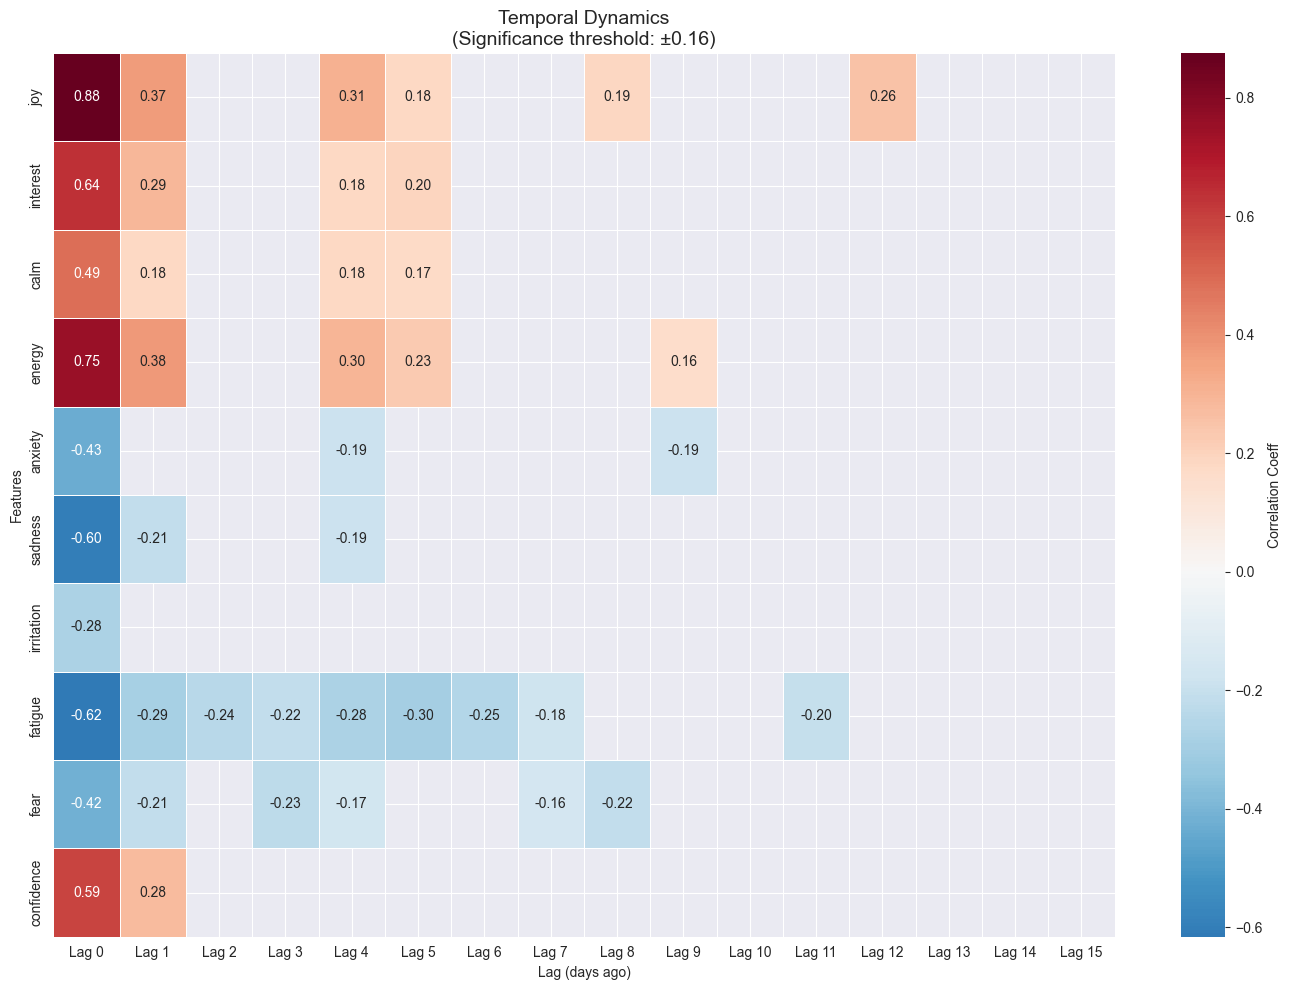

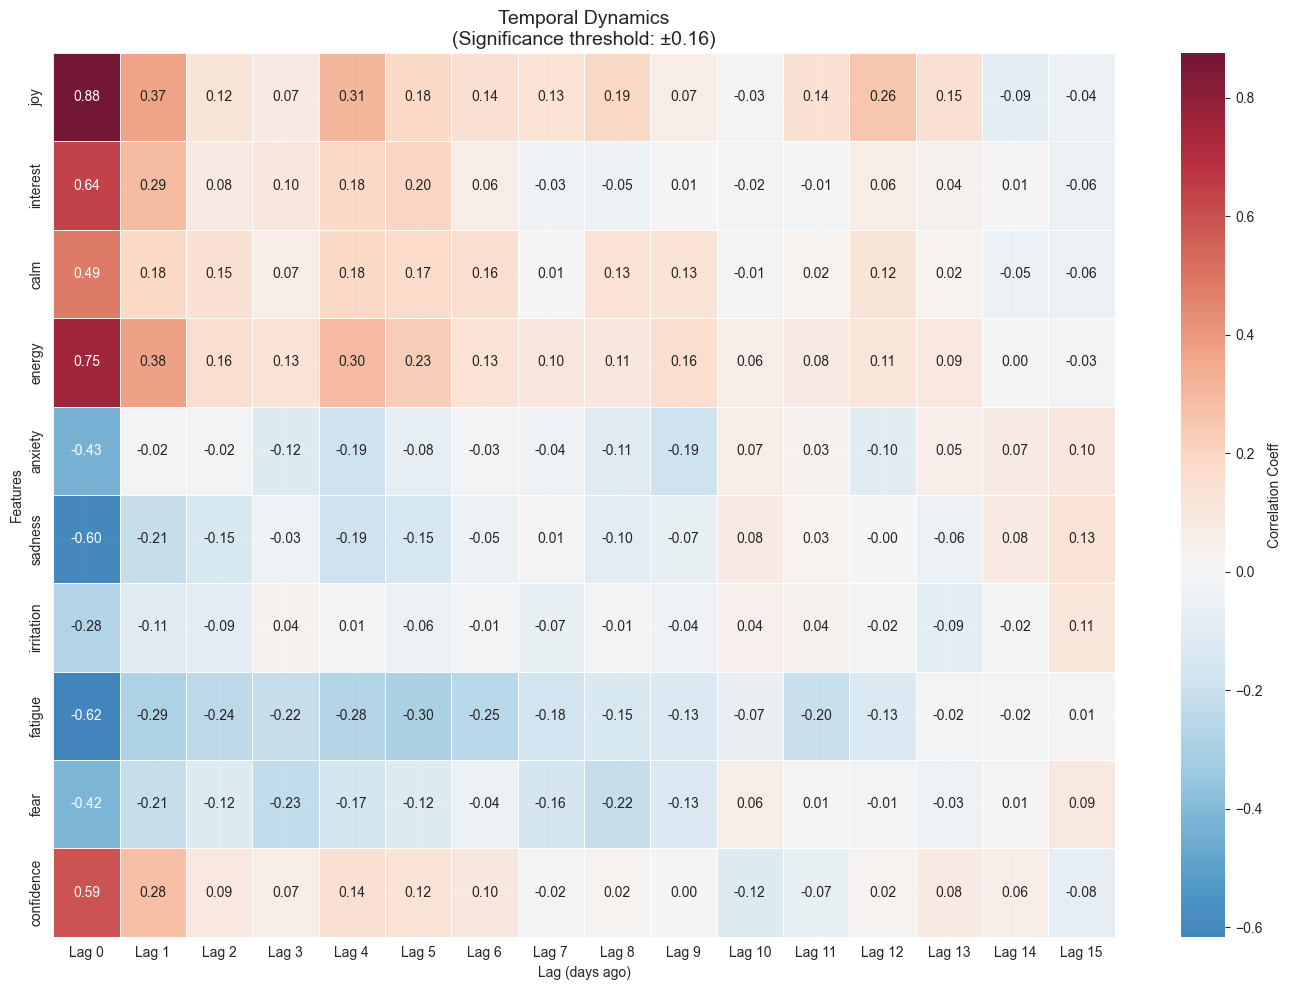


--- Summary of Added Emotion Features ---
joy         : Lags [1, 4, 5, 8, 12]
interest    : Lags [1, 4, 5]
calm        : Lags [1, 4, 5]
energy      : Lags [1, 4, 5, 9]
anxiety     : Lags [4, 9]
sadness     : Lags [1, 4]
fatigue     : Lags [1, 2, 3, 4, 5, 6, 7, 11]
fear        : Lags [1, 3, 4, 7, 8]
confidence  : Lags [1]


In [14]:
moods_features = [c for c in MOOD_COLUMNS if c not in FACTORS]

ccf_synthetic_bridge_matrix, synthetic_bridge_threshold = calculate_feature_lags_matrix(
    dfs_train_only, moods_features, [DatasetPeriod.FULL, DatasetPeriod.MOODS_ONLY]
)

plot_temporal_heatmap(ccf_synthetic_bridge_matrix, synthetic_bridge_threshold, with_noise=False)
plot_temporal_heatmap(ccf_synthetic_bridge_matrix, synthetic_bridge_threshold, with_noise=True)


clean_pairs = ccf_synthetic_bridge_matrix.drop(columns=["Lag 0"], errors="ignore").stack()
clean_pairs = clean_pairs[abs(clean_pairs) > synthetic_bridge_threshold]

grouped_lags = defaultdict(dict)

for (emotion, lag_name), corr in clean_pairs.items():
    lag_val = int("".join(filter(str.isdigit, str(lag_name))))
    grouped_lags[emotion][lag_val] = corr

for emotion, correlates in grouped_lags.items():
    emotions_features = extract_lag_features(df_raw, emotion, list(correlates.keys()), correlates)
    all_features.append({f"{emotion}_features": emotions_features})

print("\n--- Summary of Added Emotion Features ---")
for emotion, lags in grouped_lags.items():
    sorted_lags = sorted(lags.keys())
    print(f"{emotion:<12}: Lags {sorted_lags}")

* **Visualization:** Two maps (with and without noise) are constructed, showing the dynamics of the influence of each emotion.
* **Automation:** The code automatically groups significant lags for each emotion and creates corresponding features, cutting off random correlations.

### 3.5. Optimal aggregation windows
We analyze how well the long-term averages correlate with the current state.

In [15]:
target_memory_results = analyze_temporal_memory(df_raw_train, "target_final", "target_final")

# Display only statistically significant results (p-value < 0.05)
print("--- Significant Target Memory Features ---")
display(target_memory_results[target_memory_results["is_significant"]].head(10))

target_final_ewm_features = extract_ewm_features(
    df_raw, "target_final", [4, 12, 23], {4: 0.3998, 12: 0.3750, 23: 0.3431}
)

all_features.append({"target_final_ewm_features": target_final_ewm_features})

--- Significant Target Memory Features ---


,correlation,p_value,is_significant
feature,,,
target_final_ewm_5,0.400159,4.274358e-07,True
target_final_ewm_4,0.399847,4.371863e-07,True
target_final_ewm_6,0.398371,4.862576e-07,True
target_final_ewm_3,0.396548,5.541962e-07,True
target_final_ewm_7,0.395298,6.059204e-07,True
target_final_sma_5d,0.392771,1.026496e-06,True
target_final_ewm_8,0.391516,7.918823e-07,True
target_final_ewm_2,0.390435,8.542860e-07,True
target_final_ewm_9,0.387407,1.055123e-06,True


**Conclusions**:
* **EWM 4 (~0.34):** Captures rapid trend changes.
* **EWM 12 (~0.30):** Represents the "stable background" of the last two weeks. Allows the model to compare today's surge with the overall context.
* **EWM 23 (~0.28):** Indicates long-term "seasonal" sentiment or lingering phases.

### 3.6. Automatic selection of critical features
We analyze how long-term averages correlate with the current state.

Smart filtering and generation. These cells implement the final stage of preparation:

* **Clean Cross-Correlation:** The influence of each factor on the "pure" mood is calculated (without taking into account the factor itself in the target), which removes the mathematical dependence.
* **Top-N selection:** Only the top 3 most significant aggregations for each emotion are selected.
* **Dynamic Generation:** Using regular expressions (`parse_feature_name`), the system automatically creates names and calculates SMA/EWM for the selected emotions.

In [16]:
stats_mixed = get_clean_cross_corr(dfs_train_only, target_type="mixed")

st_mx_clean = get_critical_features(stats_mixed, top_n=3)


def parse_feature_name(name):
    pattern = r"^(.*)_(sma|ewm)_(\d+d?)$"
    match = re.match(pattern, name)

    if match:
        emotion, method, value = match.groups()
        clean_value = int(value.replace("d", ""))
        return emotion, method, clean_value

    return None, None, None


grouped_emotions = defaultdict(dict)

for name in st_mx_clean.index:
    emotion, method, clean_value = parse_feature_name(name)
    corr = st_mx_clean.loc[name]["correlation"]
    if clean_value == 1:
        continue
    grouped_emotions[(emotion, method)][clean_value] = float(corr)
for (emotion, method), cors in grouped_emotions.items():
    if method == "sma":
        em_features = extract_rolling_mean_features(df_raw, emotion, list(cors.keys()), cors)
    elif method == "ewm":
        em_features = extract_ewm_features(df_raw, emotion, list(cors.keys()), cors)
    else:
        continue
    all_features.append({f"{emotion}_{method}_features": em_features})

display(st_mx_clean.head(15))

,correlation,p_value,is_significant,emotion_base,abs_corr
feature,,,,,
sleep_sma_11d,0.440230,7.324071e-08,True,sleep,0.440230
sleep_sma_12d,0.437989,9.684408e-08,True,sleep,0.437989
sleep_sma_13d,0.423115,3.176532e-07,True,sleep,0.423115
joy_ewm_9,0.390164,8.706615e-07,True,joy,0.390164
joy_ewm_8,0.390122,8.732566e-07,True,joy,0.390122
joy_ewm_10,0.389647,9.027348e-07,True,joy,0.389647
energy_ewm_4,0.380876,1.652104e-06,True,energy,0.380876
energy_ewm_5,0.380818,1.658556e-06,True,energy,0.380818
energy_ewm_3,0.379315,1.836362e-06,True,energy,0.379315


**Conclusion to Stage 3**: From Raw Data to Predictive Context

This stage was a critical evolutionary step in the development of the pipeline. We transformed static mood records into a multidimensional space of temporal features that reflect the dynamics of the respondent's mood.

**Key Results**:
1. Data Cleanliness: By implementing Shielding (data shift) and Clean Cross-Correlation, we eliminated the risk of overfitting (Data Leakage) and mathematical dependence when the target "knows" the value of a factor in advance.
2. Insights: We didn't just generate features, but statistically justified their choice (PACF, CCF), determining what exactly affects mood — from short-term fluctuations (Lag 1) to "weekly echo" (Lag 11, the effect of sleep).
3. Modeling readiness: The final all_features dataset now consists of the most informative aggregations (SMA/EWM) that are statistically significant and have high predictive weight.

We have moved from trying to predict the state "here and now" to modeling the state as a function of the previous context.

## 4. Analysis of calendar cyclicity and context
This stage is dedicated to testing hypotheses about the influence of time on emotional state and generating features describing these days.

### 4.1. Testing the hypotheses about cyclicality
Before adding calendar features to the model, we need to check whether they have real predictive power to avoid overfitting on random noise.
#### 4.1.1. Analysis of weekday (ANOVA)
We test whether there are persistent differences in mood between Monday, Tuesday, and other days of the week.

In [17]:
df_raw_train["day_of_week"] = df_raw_train.index.dayofweek

groups = [df_raw_train[df_raw_train["day_of_week"] == i]["target_final"].dropna() for i in range(7)]
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Day of the week has a statistically significant effect!")
else:
    print("Day of the week is more of a noise than a stable factor.")

ANOVA p-value: 0.8008
Day of the week is more of a noise than a stable factor.


**Result**: p-value: 0.8008

**Conclusion**: No effect of specific day of the week was found. Mood is evenly distributed, which refutes the stereotype of "difficult Mondays" in this dataset.

#### 4.1.2. Weekdays and Weekends Comparison
Perhaps an aggregated indicator "weekends vs weekdays" would provide more information?

In [18]:
df_raw_train["is_weekend"] = df_raw_train.index.dayofweek.isin([5, 6]).astype(int)


weekday_mood = df_raw_train[df_raw_train["is_weekend"] == 0]["target_final"].dropna()
weekend_mood = df_raw_train[df_raw_train["is_weekend"] == 1]["target_final"].dropna()

t_stat, p_val = stats.ttest_ind(weekday_mood, weekend_mood)

print(f"T-test p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Is_weekend is a SIGNIFICANT factor!")
else:
    print("Is_weekend is just noise. No stable difference found.")

T-test p-value: 0.1990
Is_weekend is just noise. No stable difference found.


**Result**: p-value: 0.1990

**Conclusion**: Even in the binary format (weekend/weekday), no statistically significant difference was found. This means that calendar rest is not a direct driver of mood.

#### 4.1.3. Weekly Phase Analysis (Seasonality)
We check whether the mood changes from week to week (more global trends).

In [19]:
weeks = df_raw_train.index.isocalendar().week
df_raw_train["week_num"] = weeks

week_groups = [
    df_raw_train[df_raw_train["week_num"] == w]["target_final"].dropna()
    for w in df_raw_train["week_num"].unique()
]
f_stat_w, p_val_w = stats.f_oneway(*week_groups)

print(f"ANOVA (Week) p-value: {p_val_w:.4f}")

ANOVA (Week) p-value: 0.0000


**Result**: p-value: 0.0000
**Conclusion**: An extremely strong effect was found. This confirms that mood does not depend on the day of the week, but on the "life context" of a particular week (projects, events, well-being over the 7 days).

### 4.2. Contextual feature generation
Based on the results, we form a feature extraction function. We add not only calendar data, but also mood "volatility" metrics.

**Extract_calendar_features function**
This function creates a set of predictors that help the model understand the current context:
1. is_weekend: Although the test showed low significance, we leave it to capture possible nonlinear interactions.
2. mood_volatility_7d: Standard deviation of mood over the last 7 days (shifted by 1 day to avoid Leakage). Allows you to understand how stable the user's state was.
3. mood_weekly_context: Moving average for the week. Reflects the "emotional background" against which today's event occurs.
4. month_day_sin / cos: Cyclic encoding of the day of the month. Using trigonometric functions allows the model to understand that the 31st number and the 1st number are next to each other.

In [20]:
def extract_calendar_features(df):
    features = pd.DataFrame(index=df.index)

    features["is_weekend"] = df.index.dayofweek.isin([5, 6]).astype(int)
    features["mood_volatility_7d"] = df["target_final"].shift(1).rolling(window=7).std()

    features["mood_weekly_context"] = df["target_final"].shift(1).rolling(window=7).mean()

    features["week_of_year"] = df.index.isocalendar().week.astype(int)

    days_in_month = 30.5
    features["month_day_sin"] = np.sin(2 * np.pi * df.index.day / days_in_month)
    features["month_day_cos"] = np.cos(2 * np.pi * df.index.day / days_in_month)

    return features


calendar_features = extract_calendar_features(df_raw)
all_features.append({"calendar_features": calendar_features})

**Conclusion to Stage 4**

The analysis showed that local cyclicality (days of the week) is secondary to global context (weekly phases).

This is an important insight: for accurate mood prediction, it is more important for the model to know "how the past week went" (mood_weekly_context) than whether today is Monday.

Introducing cyclical coding for days of the month and calculating volatility create a solid foundation for the model to distinguish between random mood swings and systematic changes in the emotional background. We are ready to combine all features into a final vector for training.

## 5. Feature Engineering
At this stage, we create a set of engineered features that allow the model to see not only a "slice" of the emotional state, but also its dynamics, duration, and hidden relationships.

In [21]:
all_features_gen = []

### 5.1. Volatility Analysis
**Function: extract_std_features**
This function calculates the moving standard deviation for the underlying emotions and the target variable.

* **Volatility:** Allows the model to understand how stable or chaotic the mood has been over the past 7 days.
* **Leakage Prevention:** We use a 1-day lag so that the model does not see future values when calculating the deviation.
* **Stability:** A low std value indicates a stable emotional background, while a high one indicates instability.

In [22]:
def extract_std_features(df, max_window=7):
    features = pd.DataFrame(index=df.index)

    all_cols = MOOD_COLUMNS + ["target_final"]

    for col in all_cols:
        for window in range(2, max_window + 1):
            features[f"{col}_std_{window}d"] = (
                df[col].shift(1).rolling(window=window, min_periods=2).std().fillna(0)
            )
    return features


std_features = extract_std_features(df_raw)
all_features_gen.append({"std_features": std_features})

### 5.2. Historical Trigger Detection
**Function: extract_multi_day_historical_features**
Creates binary flags (0 or 1) that signal the presence of certain states in the past.

* **Memory:** The model learns whether "critical" states (e.g., severe anxiety or severe good) have occurred in the last 8 days.
* **Sliding window:** Using `.max()` on a sliding window allows us to capture the very fact of an event, even if it happened only once.
* **Flexibility:** We separately allocate "severe" cases for anxiety, irritation, sadness, and fatigue.

In [56]:
def extract_multi_day_historical_features(df, max_days=8):
    features = pd.DataFrame(index=df.index)

    # Iterate over each window from 2 to the given maximum
    for days in range(2, max_days + 1):
        suffix = f"last_{days}d"

        # 1. Good moods (GOOD_MOOD_COLUMNS)
        for mood in GOOD_MOOD_COLUMNS:
            # Was it 4 (severe good) in the last N days
            features[f"had_severe_{mood}_{suffix}"] = (
                (df[mood] == 4)
                .rolling(window=days, min_periods=1)
                .max()
                .shift(1)
                .fillna(0)
                .astype(int)
            )
            # Was there a 1 (severe bad) in the last N days
            features[f"had_severe_bad_{mood}_{suffix}"] = (
                (df[mood] == 1)
                .rolling(window=days, min_periods=1)
                .max()
                .shift(1)
                .fillna(0)
                .astype(int)
            )

        # 2. Anxiety
        features[f"had_severe_anxiety_{suffix}"] = (
            (df["anxiety"] == 4)
            .rolling(window=days, min_periods=1)
            .max()
            .shift(1)
            .fillna(0)
            .astype(int)
        )
        features[f"had_not_severe_anxiety_{suffix}"] = (
            (df["anxiety"] == 1)
            .rolling(window=days, min_periods=1)
            .max()
            .shift(1)
            .fillna(0)
            .astype(int)
        )

        # 3. Sadness, fatigue, fear
        for mood in ["sadness", "fatigue", "fear"]:
            features[f"had_severe_{mood}_{suffix}"] = (
                (df[mood] > 2)
                .rolling(window=days, min_periods=1)
                .max()
                .shift(1)
                .fillna(0)
                .astype(int)
            )
            features[f"had_{mood}_{suffix}"] = (
                (df[mood] == 2)
                .rolling(window=days, min_periods=1)
                .max()
                .shift(1)
                .fillna(0)
                .astype(int)
            )
            features[f"had_not_{mood}_{suffix}"] = (
                (df[mood] == 1)
                .rolling(window=days, min_periods=1)
                .max()
                .shift(1)
                .fillna(0)
                .astype(int)
            )

        # 4. Irritation
        features[f"had_severe_irritation_{suffix}"] = (
            (df["irritation"] > 1)
            .rolling(window=days, min_periods=1)
            .max()
            .shift(1)
            .fillna(0)
            .astype(int)
        )

    return features


historical_features_all = extract_multi_day_historical_features(df_raw, max_days=8)

all_features_gen.append({"historical_features_all": historical_features_all})

C:\Users\myros\AppData\Local\Temp\ipykernel_18168\4033195941.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'had_severe_{mood}_{suffix}'] = (
C:\Users\myros\AppData\Local\Temp\ipykernel_18168\4033195941.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'had_severe_bad_{mood}_{suffix}'] = (
C:\Users\myros\AppData\Local\Temp\ipykernel_18168\4033195941.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

### 5.3. Streak and Recovery Analysis
**Function: extract_mood_streak_features**
This function estimates how long a user has been in a certain state or how long ago a target mood was achieved.

* **Days Strike:** Shows how many consecutive days the current mood has lasted (important for depressive or consistently good periods).
* **Days Since:** Counts how much time has passed since the last time a goal or a certain emotion was achieved.
* **Group Logic:** Using a cumulative sum allows you to correctly group sequences of states.

In [24]:
def extract_mood_streak_features(df, target_col="target_final"):
    features = pd.DataFrame(index=df.index)

    target = df[target_col].shift(1)

    conditions = {"bad": target < 4, "normal": target == 4, "good": target == 5, "best": target > 5}

    for mood_name, condition in conditions.items():
        # --- 1. Days Since ---
        # Create a mask: where the condition is met — there is 0, where not — there is 1
        # cumsum() creates groups. In each group we count the days since the last "success"
        is_event = condition.astype(int)

        # Count the days since the last event
        # cumsum breaks the data into blocks by events. Within a block, cumcount counts the days.
        day_counter = condition.groupby(is_event.cumsum()).cumcount()

        # If the event has never happened before (first few lines), set it to 0
        features[f"days_since_last_{mood_name}_mood"] = np.where(
            is_event.cumsum() == 0, 0, day_counter
        )

        # --- 2. Strike (Series of consecutive days) ---
        # We define blocks of identical values (True or False)
        streak_groups = (condition != condition.shift()).cumsum()
        features[f"{mood_name}_days_strike"] = (
            condition.groupby(streak_groups).cumcount() + 1
        ) * condition.astype(int)

    return features


streak_target_final_features = extract_mood_streak_features(df_raw)
all_features_gen.append({"streak_target_final_features": streak_target_final_features})

### 5.4. Dynamics of changes (Deltas)
**Function: extract_mood_deltas_features**
Calculates the vector of mood change compared to previous days.

* **Trend:** Shows the speed and direction of changes (improvement or deterioration).
* **Motion vector:** The difference between "yesterday" and "N days ago" gives an understanding of whether the state is getting better or the emotional background is subsiding.
* **Settings:** We iterate up to 8 days back, which allows us to capture medium-term changes in mood.

In [25]:
def extract_mood_deltas_features(df, max_days=8):
    features = pd.DataFrame(index=df.index)

    for col in MOOD_COLUMNS:
        # We take "yesterday's" value as a basis for comparison
        base_lag_1 = df[col].shift(1)

        # We iterate from 1 to a given maximum
        # (difference from the day before yesterday, 3 days ago, etc.)
        for days in range(1, max_days + 1):
            # Value (N + 1) days ago to compare with lag_1
            past_lag = df[col].shift(days + 1)

            # A positive value means a metric is growing,
            # a negative value means a metric is falling.
            features[f"{col}_delta_{days}d"] = base_lag_1 - past_lag

    return features


deltas_features = extract_mood_deltas_features(df_raw, max_days=8)
all_features_gen.append({"deltas_features": deltas_features})

### 5.5. Interactions and smoothing
**Functions: extract_rolling_interactions and extract_ewm_features**
Combine metrics to find synergies and smooth out noise.

* **Rolling Interactions:** Multiplying the average values of "good" and "bad" emotions over different windows. Allows you to detect moments when the impact of one state is amplified by another.
* **EWM (Exponential Moving Average):** Gives more weight to recent data. This better simulates the human psyche, where events from yesterday are more important than events from a week ago.

In [26]:
DEFAULT_WINDOWS = [2, 3, 4, 5, 6, 7, 8]


def extract_rolling_interactions(df, windows=DEFAULT_WINDOWS):
    features = {}
    target_cols = list(set(GOOD_MOOD_COLUMNS + BAD_MOOD_COLUMNS))
    df_shifted = df[target_cols].shift(1)

    for w in windows:
        rolling_df = df_shifted.rolling(window=w).mean()

        for good in GOOD_MOOD_COLUMNS:
            for bad in BAD_MOOD_COLUMNS:
                col_name = f"{good}_x_{bad}_roll_{w}"
                features[col_name] = rolling_df[good] * rolling_df[bad]

    return pd.DataFrame(features, index=df.index)


def extract_ewm_features(df, spans=DEFAULT_WINDOWS):
    features = {}
    target_cols = list(set(GOOD_MOOD_COLUMNS + BAD_MOOD_COLUMNS))
    df_shifted = df[target_cols].shift(1)

    for s in spans:
        ewm_df = df_shifted.ewm(span=s).mean()

        for col in target_cols:
            features[f"{col}_ewm_{s}"] = ewm_df[col]

    return pd.DataFrame(features, index=df.index)


extract_rolling_interactions_features = extract_rolling_interactions(df_raw)
all_features_gen.append(
    {"extract_rolling_interactions_features": extract_rolling_interactions_features}
)

extract_ewm_features_features = extract_ewm_features(df_raw)
all_features_gen.append({"extract_ewm_features_features": extract_ewm_features_features})

### 5.6. Cross-interactions with lag
**Function: extract_cross_interactions_features**
Create complex features based on the interactions of different emotions in the past.

* **Synergy with a delayed effect:** Sometimes the effect of combining two emotions (e.g. fatigue + anxiety) only appears after a few days.
* **Multiplicative and additive features:** We generate both types of interactions so that the model can easily capture both the amplification of effects (product) and their accumulation (sum).

In [27]:
def extract_cross_interactions_features(df, max_days=8):
    features = pd.DataFrame(index=df.index)

    for days in range(1, max_days + 1):
        for good_col in GOOD_MOOD_COLUMNS:
            for bad_col in BAD_MOOD_COLUMNS:
                # Metric values N days ago
                good_lag = df[good_col].shift(days)
                bad_lag = df[bad_col].shift(days)

                # Multiplicative interaction
                features[f"{good_col}_x_{bad_col}_lag_{days}"] = good_lag * bad_lag

                # Additive interaction (sometimes works better for linear models)
                features[f"{good_col}_plus_{bad_col}_lag_{days}"] = good_lag + bad_lag

    return features


cross_interactions_features = extract_cross_interactions_features(df_raw, max_days=8)
all_features_gen.append({"cross_interactions_features": cross_interactions_features})

In [28]:
for feat in [*all_features, *all_features_gen]:
    print(list(feat.keys())[0])
    print(list(feat.values())[0].columns)

target_mood_lags
Index(['target_final_lag_1_corr_0.383', 'target_final_lag_4_corr_0.301',
       'target_final_lag_11_corr_0.226'],
      dtype='object')
sleep_features
Index(['sleep_lag_11_corr_0.271', 'sleep_lag_7_corr_0.285',
       'sleep_lag_5_corr_0.225', 'sleep_lag_2_corr_0.198',
       'sleep_lag_6_corr_0.183', 'sleep_lag_9_corr_0.181'],
      dtype='object')
joy_features
Index(['joy_lag_1_corr_0.369', 'joy_lag_4_corr_0.313', 'joy_lag_5_corr_0.178',
       'joy_lag_8_corr_0.188', 'joy_lag_12_corr_0.255'],
      dtype='object')
interest_features
Index(['interest_lag_1_corr_0.291', 'interest_lag_4_corr_0.178',
       'interest_lag_5_corr_0.196'],
      dtype='object')
calm_features
Index(['calm_lag_1_corr_0.177', 'calm_lag_4_corr_0.178',
       'calm_lag_5_corr_0.173'],
      dtype='object')
energy_features
Index(['energy_lag_1_corr_0.377', 'energy_lag_4_corr_0.297',
       'energy_lag_5_corr_0.226', 'energy_lag_9_corr_0.161'],
      dtype='object')
anxiety_features
Index(['anxie

We have transformed static mood records into dynamic vectors that take into account time and context.

**Main types of features**:
1. Volatility: Measures the "volatility" of the emotional background (std).
2. Historical triggers: Captures "was there anything bad/good in the past?" (max).
3. Streaks and inertia: Assesses how long the state lasts and how quickly recovery occurs.
4. Deltas: Shows the direction and speed of mood movement (trend).
5. Interactions and EWM: Reveals synergy of emotions and gives more weight to current events.

## 6. Feature Dataset Finalization — `build_feature_df`

The `build_feature_df` function aggregates manual and auto-generated features, removes noise and multicollinearity, and produces a clean, leak-free dataset for model training.

> **Key guarantee:** the function receives only training data (`df_raw_train`), fully excluding any information from the test holdout.

---

### Internal pipeline

**`extract_dfs(all_features)`**  
Accepts heterogeneous structures (dicts, lists, DataFrames) and flattens them into a single list of DataFrames. This allows adding new feature sources without rewriting the pipeline.

**`filter_corr_cols(df, min_signal_corr)`**  
Filters columns named with the pattern `*_corr_X` by reading the correlation value directly from the column name. Features with `|corr| < min_signal_corr` (default 0.1) are dropped before any merging occurs.

**`drop_collinear(df, threshold)`**  
Builds a pairwise absolute correlation matrix on training rows only (`iloc[:-14]`) and removes features that exceed `threshold` with any other feature. The upper triangle of the matrix is used (`np.triu`) to avoid duplicate comparisons. When two features are collinear, the one appearing **later** in the DataFrame is dropped — meaning manual features, placed first, are protected over generated ones.

**`select_top_generated(df, target, top_n)`**  
Ranks generated features by absolute Pearson correlation with the target, computed on training rows only (`iloc[:-14]`). Selects the top-N candidates, discarding the rest before the merge step.

---

### Execution order

| Step | Action |
|------|--------|
| 1 | Concatenate `manual_features` → filter weak signals → remove collinear |
| 2 | Concatenate `generated_features` → filter weak signals → remove collinear → select top-N |
| 3 | Merge both groups; drop exact duplicate columns |
| 4 | Final collinearity check **between** manual and generated groups (manual columns take priority) |
| 5 | `dropna()` — removes rows with NaN introduced by `shift`/`rolling` operations |
| 6 | Attach target via `df_raw.loc[df_final.index, "target_final"]` — index-safe join that survives row drops |

**Output:** a DataFrame where each row is one day, each column is a cleaned feature, and no future information has leaked into any observation.

In [29]:
def build_feature_df(
    manual_features,  # all_features that made by myself
    generated_features,  # all_features that generated
    df_raw,
    manual_corr_threshold=0.85,
    generated_corr_threshold=0.4,
    final_corr_threshold=0.8,
    min_signal_corr=0.1,  # minimum correlation with the target for selection
    top_n_generated=20,  # how many best features from the generated ones to take
):
    def extract_dfs(all_features):
        dfs = []
        for item in all_features:
            if isinstance(item, dict):
                for val in item.values():
                    if isinstance(val, pd.DataFrame):
                        dfs.append(val)
                    elif isinstance(val, (list, tuple, type({}.values()))):
                        dfs.extend([df for df in val if isinstance(df, pd.DataFrame)])
            elif isinstance(item, pd.DataFrame):
                dfs.append(item)
        return dfs

    def filter_corr_cols(df, min_signal_corr):
        """Filter the corr columns by minimum signal"""
        corr_cols = [col for col in df.columns if "corr_" in col]
        valid_cols = []
        for col in corr_cols:
            try:
                corr_value = float(col.split("corr_")[-1])
                if abs(corr_value) >= min_signal_corr:
                    valid_cols.append(col)
            except ValueError:
                continue
        other_cols = [col for col in df.columns if "corr_" not in col]
        return df[other_cols + valid_cols]

    def drop_collinear(df, threshold):
        """Removing multicollinear features"""
        split_point = len(df) - 14
        df_train_only = df.iloc[:split_point]
        corr_matrix = df_train_only.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
        print(f"   Removed {len(to_drop)} collinear: {to_drop}")
        return df.drop(columns=to_drop)

    def select_top_generated(df, target, top_n):
        """We select the top N features by correlation with the target"""
        split_point = len(df) - 14
        corrs = df.iloc[:split_point].corrwith(target.iloc[:split_point]).abs()
        top_cols = corrs.nlargest(top_n).index.tolist()
        dropped = len(df.columns) - len(top_cols)
        print(f"   Selected top {top_n} of {len(df.columns)} generated (dropped {dropped})")
        return df[top_cols]

    # --- MANUAL ---
    print("📦 Processing manual features...")
    df_manual = pd.concat(extract_dfs(manual_features), axis=1)
    df_manual = filter_corr_cols(df_manual, min_signal_corr)
    df_manual = drop_collinear(df_manual, manual_corr_threshold)

    # --- GENERATED ---
    print("\n🤖 Processing generated features...")
    df_generated = pd.concat(extract_dfs(generated_features), axis=1)
    df_generated = filter_corr_cols(df_generated, min_signal_corr)
    df_generated = drop_collinear(df_generated, generated_corr_threshold)
    df_generated = select_top_generated(df_generated, df_raw["target_final"], top_n_generated)
    print(f"{df_generated=}")

    print("\n🔗 Merge and final cleanup...")
    df_final = pd.concat([df_manual, df_generated], axis=1)

    df_final = df_final.loc[:, ~df_final.columns.duplicated()]

    df_final = drop_collinear(df_final, final_corr_threshold)

    df_final = df_final.dropna()

    df_final["target_final"] = df_raw.loc[df_final.index, "target_final"]

    print(f"\n✅ Final dataset: {df_final.shape[1] - 1} feature + target")
    return df_final


df_final = build_feature_df(
    manual_features=all_features,
    generated_features=all_features_gen,
    df_raw=df_raw,
    manual_corr_threshold=0.85,
    generated_corr_threshold=0.60,
    final_corr_threshold=0.8,
    top_n_generated=45,
)

📦 Processing manual features...
   Removed 24 collinear: ['joy_lag_1_corr_0.369', 'joy_lag_4_corr_0.313', 'target_final_ewm_4_corr_0.400', 'target_final_ewm_12_corr_0.375', 'target_final_ewm_23_corr_0.343', 'sleep_sma_11d_corr_0.440', 'sleep_sma_12d_corr_0.438', 'sleep_sma_13d_corr_0.423', 'joy_ewm_9_corr_0.390', 'joy_ewm_8_corr_0.390', 'joy_ewm_10_corr_0.390', 'energy_ewm_5_corr_0.381', 'energy_ewm_3_corr_0.379', 'calm_sma_6d_corr_0.321', 'calm_sma_8d_corr_0.312', 'interest_ewm_2_corr_0.291', 'confidence_ewm_2_corr_0.255', 'anxiety_sma_10d_corr_-0.236', 'anxiety_sma_9d_corr_-0.274', 'sadness_ewm_3_corr_-0.230', 'sadness_sma_5d_corr_-0.246', 'fear_sma_8d_corr_-0.283', 'fatigue_ewm_8_corr_-0.384', 'fatigue_sma_6d_corr_-0.387']

🤖 Processing generated features...
   Removed 925 collinear: ['joy_std_3d', 'joy_std_4d', 'joy_std_5d', 'joy_std_6d', 'joy_std_7d', 'interest_std_3d', 'interest_std_4d', 'interest_std_5d', 'interest_std_6d', 'interest_std_7d', 'calm_std_3d', 'calm_std_4d', 'calm_

### `build_feature_df` — execution summary

| Stage | Details |
|-------|---------|
| Manual features — collinear removed | **24** redundant features dropped (overlapping EWM/SMA windows for `joy`, `sleep`, `fatigue`, `energy`, `calm`, `anxiety`, `sadness`, `fear`) |
| Generated features — collinear removed | **925** features dropped (primarily `std_Nd` rolling windows across all emotions) |
| Generated features — top selected | **45** features retained out of the reduced pool |
| Final cross-group collinearity check | **3** generated features removed that duplicated manual signals (`energy_ewm_4`, `fear_sma_9d`, `calm_ewm_2`) |
| **Final dataset shape** | **95 features + 1 target** across 146 rows |

The aggressive removal at the generated stage (925 columns) confirms that auto-generated rolling `std` features are highly redundant with each other and carry little independent signal. The manual features survived almost intact, validating the domain-driven engineering approach.

## 7. Train / Test Split

The dataset is split chronologically into a training set and a fixed 14-day holdout.


In [31]:
X = df_final.drop(columns=["target_final"])
y = df_final["target_final"]

X_train, X_test = X.iloc[:-14], X.iloc[-14:]
y_train, y_test = y.iloc[:-14], y.iloc[-14:]

## 8. Preliminary Feature Importance — CatBoost on Full Feature Space

Before running the full model comparison, a lightweight CatBoost is trained across `TimeSeriesSplit` folds on all 95 features to estimate their average importance. This step serves as a pre-filter: features are ranked by mean split-based importance across folds, and only the ranked list is passed downstream — no features are dropped here.

`early_stopping_rounds=50` prevents overfitting within each fold by halting training when validation loss stops improving. Importance scores are averaged across all folds before ranking, making the estimate more stable than a single-run importance.

`TimeSeriesSplit(n_splits=5)` is used here intentionally — more folds 
produce a more stable mean importance estimate. This differs from `n_splits=3` 
used in model comparison (Section 9), where a smaller split count 
preserves more training data per fold.

In [32]:
tscv = TimeSeriesSplit(n_splits=5)
importances = []

for train_idx, val_idx in tscv.split(X):
    model = CatBoostRegressor(iterations=500, silent=True, random_seed=42)
    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx],
        eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
        early_stopping_rounds=50,
    )
    importances.append(model.get_feature_importance())

mean_importance = np.mean(importances, axis=0)
feature_importance_df = pd.DataFrame({"feature": X.columns, "importance": mean_importance})
top_features = feature_importance_df.sort_values(by="importance", ascending=False)
top_features

,feature,importance
5,month_day_cos,5.030285
63,joy_delta_8d,3.352546
3,week_of_year,2.667599
7,target_final_lag_4_corr_0.301,2.400512
24,energy_lag_1_corr_0.377,2.390458
...,...,...
77,best_days_strike,0.286955
29,anxiety_lag_9_corr_-0.187,0.225045
73,had_severe_bad_calm_last_2d,0.209094
64,had_severe_bad_interest_last_2d,0.176396


The filtered datasets preserve the full feature set but in descending importance order, which allows `SequentialFeatureSelector` in the next section to prioritize the most informative candidates when `n_features` is small.

In [33]:
selected_top_list = top_features["feature"].tolist()

X_train_filtered = X_train[selected_top_list]
X_test_filtered = X_test[selected_top_list]

In [34]:
print(selected_top_list[:10])

['month_day_cos', 'joy_delta_8d', 'week_of_year', 'target_final_lag_4_corr_0.301', 'energy_lag_1_corr_0.377', 'target_final_lag_1_corr_0.383', 'fatigue_ewm_9_corr_-0.383', 'calm_delta_6d', 'interest_delta_6d', 'fatigue_lag_5_corr_-0.301']


## 9. Model Comparison, Fine-tuning & Final Evaluation

This section implements the full modelling pipeline:
- automated feature selection per model type
- cross-validated grid search
- fine-tuning of promising candidates
- rolling-window final evaluation
- permutation importance analysis

The pipeline is split into utility functions, constants, and an orchestration block to keep each responsibility isolated and testable.

### 9.1 Visualization Utilities

**`plot_learning_curve`** trains the estimator on progressively larger subsets of the training data and plots MAE for both training and validation sets. The shaded band shows ±1 standard deviation across CV folds. An automatic diagnosis is displayed on the chart:

| Condition | Label | Meaning |
|-----------|-------|---------|
| Gap > 0.30 | `[WARN]` | Strong overfitting |
| Both curves > 0.70 | `[LOW]` | Underfitting |
| Gap > 0.15 | `[MID]` | Moderate overfitting — increase regularization |
| Otherwise | `[OK]` | Healthy balance |

**`plot_permutation_importance`** measures feature importance in a model-agnostic way: each feature is randomly shuffled and the resulting drop in R² is recorded. Features with near-zero or negative contribution are candidates for removal. Unlike built-in tree importance (which is computed on training data), permutation importance is evaluated on the test set, making it a more reliable indicator of real-world utility.

In [35]:
from daily_flow.analytics.datasets.visualizations import plot_learning_curve

### 9.2 Configuration Constants

**`LINEAR_MODELS`** — list of model names that receive a pre-filtered feature candidate pool (top-15 by Pearson correlation with the target). Non-linear models receive the full ranked feature space and rely on `SequentialFeatureSelector` to navigate it.

**`MODELS_CONFIG`** — maps each model name to its estimator and the hyperparameter grid used in the initial `GridSearchCV` sweep. All estimators are wrapped inside a `StandardScaler → model` pipeline.

**`FINETUNE_PARAMS`** — a wider, more granular search space used in the second-stage `RandomizedSearchCV`. CatBoost's grid is notably larger, covering `depth`, `l2_leaf_reg`, `learning_rate`, `iterations`, `min_data_in_leaf`, `subsample`, and `bootstrap_type`.


In [36]:
from daily_flow.analytics.datasets.constants import FINETUNE_PARAMS, LINEAR_MODELS, MODELS_CONFIG

### 9.3 Diagnostics

**`diagnose_data(X_train, y_train, tscv)`**  
Prints fold sizes and the naive lag-1 baseline on the training set. This establishes the performance floor that any model must exceed to be considered useful.

**`naive_baseline_on_test(X_test, y_test)`**  
Applies the same lag-1 baseline to the held-out test set. Comparing model predictions against this value is the primary sanity check: a model with lower MAE than the baseline provides genuine predictive signal.

In [37]:
# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------


def diagnose_data(X_train, y_train, tscv):
    print("📐 Fold sizes:")
    for i, (tr, te) in enumerate(tscv.split(X_train)):
        print(f"   Fold {i + 1}: train={len(tr)} days, test={len(te)} days")

    print("\n📊 Naive baseline (assuming lag_1):")
    lag1_col = [c for c in X_train.columns if "lag_1" in c]
    if lag1_col:
        naive_preds = X_train[lag1_col[0]]
        common_idx = y_train.index.intersection(naive_preds.index)
        r2 = r2_score(y_train.loc[common_idx], naive_preds.loc[common_idx])
        mae = mean_absolute_error(y_train.loc[common_idx], naive_preds.loc[common_idx])
        print(f"   Lag-1 R²={r2:.3f}, MAE={mae:.3f}")


def naive_baseline_on_test(X_test, y_test):
    lag1_col = [c for c in X_test.columns if "lag_1" in c]
    if lag1_col:
        naive = X_test[lag1_col[0]]
        print(
            f"Naive baseline on TEST: "
            f"MAE={mean_absolute_error(y_test, naive):.3f}, "
            f"R²={r2_score(y_test, naive):.3f}"
        )

### 9.4 Feature Selection & Grid Search

**`_select_features_for_model(name, X_train, y_train, n_features, tscv)`**  
Runs `SequentialFeatureSelector` (forward direction, `r2` scoring) using `TimeSeriesSplit` CV. Linear models receive a pre-filtered pool of 15 candidates ranked by correlation; tree-based models receive the full feature space. This asymmetry reflects that linear models cannot discover interactions, so restricting to high-correlation features avoids noise amplification.

**`_fit_grid(name, selected_features, X_train, y_train, tscv)`**  
Runs `GridSearchCV` with the initial parameter grid from `MODELS_CONFIG`. Returns the best estimator fitted on the full training set.

In [38]:
def _select_features_for_model(name, X_train, y_train, n_features, tscv):
    model_for_sfs = clone(MODELS_CONFIG[name]["model"])

    if name in LINEAR_MODELS:
        corr_features = X_train.corrwith(y_train).abs().sort_values(ascending=False).index[:15]
        candidate_X = X_train[corr_features]
    else:
        candidate_X = X_train

    sfs = SequentialFeatureSelector(
        estimator=Pipeline([("scaler", StandardScaler()), ("model", model_for_sfs)]),
        n_features_to_select=n_features,
        direction="forward",
        scoring="r2",
        cv=tscv,
        n_jobs=1,
    )
    sfs.fit(candidate_X, y_train)
    selected = candidate_X.columns[sfs.get_support()].tolist()
    return selected


def _fit_grid(name, selected_features, X_train, y_train, tscv):
    model_for_pipe = clone(MODELS_CONFIG[name]["model"])
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model_for_pipe)])
    grid = GridSearchCV(
        pipe,
        MODELS_CONFIG[name]["params"],
        cv=tscv,
        scoring="r2",
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train[selected_features], y_train)
    return grid.best_estimator_

### 9.5 Multi-model Sweep — `compare_models_with_sfs`

Iterates over all models in `MODELS_CONFIG` for a given `n_features` count. For each model:
1. Selects features via SFS
2. Fits a grid search
3. Evaluates on both CV folds and the fixed holdout
4. Records CV MAE, CV R², CV R² Std, TEST MAE, TEST R²

Tree-based models are automatically skipped for `n_features > 6` to prevent overfitting on 160 samples. Learning curves are plotted for the top-6 models that pass a minimum R² threshold on both CV and test.

The outer loop runs the sweep for `n_features ∈ [3, 4, 5, 6, 7, 8]`, producing a comprehensive comparison across feature counts.

In [39]:
def compare_models_with_sfs(X_train, X_test, y_train, y_test, n_features=3):
    tscv = TimeSeriesSplit(n_splits=3, test_size=14)
    diagnose_data(X_train, y_train, tscv)

    results = []
    best_pipes = {}

    for name in MODELS_CONFIG:
        unique_name = f"{name}_{n_features}f"
        print(f"\n⏳ {unique_name}...")

        if name not in LINEAR_MODELS and n_features > 6:
            print(f"⏩ Skipping {name} for {n_features} features (risk of overfitting)")
            continue

        selected_features = _select_features_for_model(name, X_train, y_train, n_features, tscv)
        print(f"   ✅ Features: {selected_features}")

        best_pipe = _fit_grid(name, selected_features, X_train, y_train, tscv)

        cv_res = cross_validate(
            best_pipe,
            X_train[selected_features],
            y_train,
            cv=tscv,
            scoring=("neg_mean_absolute_error", "r2"),
        )
        y_pred = best_pipe.predict(X_test[selected_features])
        test_mae = mean_absolute_error(y_test, y_pred)
        test_r2 = r2_score(y_test, y_pred)
        cv_r2 = cv_res["test_r2"]

        print(f"   CV R² by folds: {np.round(cv_r2, 3)}")

        best_pipes[unique_name] = {"pipe": best_pipe, "features": selected_features}
        results.append(
            {
                "Model": unique_name,
                "Base_Model": name,
                "CV MAE": -cv_res["test_neg_mean_absolute_error"].mean(),
                "CV R2": cv_r2.mean(),
                "CV R2 Std": cv_r2.std(),
                "TEST MAE (14d)": test_mae,
                "TEST R2 (14d)": test_r2,
                "Best Params": {},
                "Selected Features": selected_features,
            }
        )

    results_df = pd.DataFrame(results).sort_values(
        by=["TEST R2 (14d)", "CV R2"], ascending=[False, False]
    )

    for i in range(min(len(results_df), 6)):
        row_name = results_df.iloc[i]["Model"]
        row_cv_r2 = float(results_df.iloc[i]["CV R2"])
        row_test_r2 = float(results_df.iloc[i]["TEST R2 (14d)"])
        info = best_pipes[row_name]

        if row_cv_r2 > -0.1 and row_test_r2 > -0.1:
            print(f"\n📈 Building a learning curve for: {row_name}")
            plot_learning_curve(
                estimator=info["pipe"],
                X=X_train[info["features"]],
                y=y_train,
                cv=tscv,
                model_name=row_name,
            )

    return results_df, best_pipes

### 9.6 Fine-tuning — `finetune_best_models`

Filters candidates by a two-criteria rule:
- CV R² > -0.1 **and** TEST R² > -0.1, **or**
- Stability Score (`CV R² - 2 × CV R² Std`) > -0.05 **and** TEST R² > -0.1

Candidates are ranked by Stability Score to prioritize consistent models over lucky-fold winners. For each candidate, `RandomizedSearchCV` with `n_iter=min(50, total_combinations)` is run over the wider `FINETUNE_PARAMS` grid. A learning curve is plotted after each fine-tune.

In [40]:
def _is_worth_finetuning(row):
    cv, tst, stab = row["CV R2"], row["TEST R2 (14d)"], row["Stability_Score"]
    if cv > -0.1 and tst > -0.1:
        return True
    if stab > -0.05 and tst > -0.1:
        return True
    return False


def finetune_best_models(results_df, best_pipes, X_train, X_test, y_train, y_test):
    tscv = TimeSeriesSplit(n_splits=3, test_size=14)

    results_df = results_df.copy()
    results_df["Stability_Score"] = results_df["CV R2"] - (results_df["CV R2 Std"] * 2)
    results_df = results_df.sort_values("Stability_Score", ascending=False)

    candidates = results_df[results_df.apply(_is_worth_finetuning, axis=1)]
    if candidates.empty:
        print("❌ No model passed the threshold")
        return pd.DataFrame()

    print(f"\n🎯 Passed the filter ({len(candidates)} models): {candidates['Model'].tolist()}")

    finetune_results = []

    for _, row in candidates.iterrows():
        unique_name = row["Model"]
        base_name = row["Base_Model"]
        features = row["Selected Features"]
        print(f"\n🔬 Fine-tune: {unique_name} (features: {len(features)})")

        X_tr, X_te = X_train[features], X_test[features]
        base_pipe = clone(best_pipes[unique_name]["pipe"])
        if base_name in FINETUNE_PARAMS:
            params = FINETUNE_PARAMS[base_name]
        else:
            print(
                f"⚠️ Warning: No parameters found in"
                f" FINETUNE_PARAMS for model {base_name}. Skipping."
            )
            continue
        total_combos = math.prod([len(v) for v in params.values() if isinstance(v, list)])
        n_iter = min(50, total_combos) if total_combos > 0 else 50

        grid = RandomizedSearchCV(
            base_pipe,
            params,
            n_iter=n_iter,
            cv=tscv,
            scoring="r2",
            n_jobs=-1,
            refit=True,
            verbose=1,
            random_state=42,
        )
        grid.fit(X_tr, y_train)
        tuned_pipe = grid.best_estimator_

        cv_res = cross_validate(
            tuned_pipe,
            X_tr,
            y_train,
            cv=tscv,
            scoring=("neg_mean_absolute_error", "r2"),
        )
        y_pred = tuned_pipe.predict(X_te)
        test_r2 = r2_score(y_test, y_pred)
        test_mae = mean_absolute_error(y_test, y_pred)
        cv_r2 = cv_res["test_r2"]

        print(f"   CV R² by folds: {np.round(cv_r2, 3)}")
        print(f"   TEST R²={test_r2:.3f}  TEST MAE={test_mae:.3f}")
        print(f"   Best params: {grid.best_params_}")

        plot_learning_curve(
            tuned_pipe, X_tr, y_train, tscv, model_name=f"{unique_name} [fine-tuned]"
        )

        finetune_results.append(
            {
                "Model": f"{unique_name} [FT]",
                "CV MAE": -cv_res["test_neg_mean_absolute_error"].mean(),
                "CV R2": cv_r2.mean(),
                "CV R2 Std": cv_r2.std(),
                "TEST MAE (14d)": test_mae,
                "TEST R2 (14d)": test_r2,
                "Best Params": grid.best_params_,
                "Selected Features": features,
            }
        )

    ft_df = pd.DataFrame(finetune_results).sort_values("CV R2", ascending=False)
    print("\n" + "=" * 80)
    print("📊 Fine-tune results:")
    print(ft_df[["Model", "CV MAE", "CV R2", "CV R2 Std", "TEST MAE (14d)", "TEST R2 (14d)"]])
    return ft_df

### 9.7 Supporting Functions — Feature Statistics & Model Summary

**`analyze_and_plot_selective(results_df)`**  
Filters configurations that passed both CV R² > -0.1 and TEST R² > -0.1, aggregates feature co-occurrence across successful models, and renders a pie chart of the most robust signals. Features appearing only once are collapsed into an "Other" slice.

**`plot_model_family_summary(results_df, ft_df, combined)`**  
Strips the feature-count suffix (e.g. `_5f`) from model names to group results by model family, then plots win-count bar charts separately for: pre-finetune configurations, fine-tuned configurations, and all configurations combined. "Win" is defined as TEST R² > -0.1 and CV R² > -0.1.

In [41]:
# ---------------------------------------------------------------------------
# Feature statistics + pie chart
# ---------------------------------------------------------------------------

feature_stats = collections.defaultdict(lambda: {"count": 0, "models": []})


def analyze_and_plot_selective(results_df):
    successful_mask = (results_df["CV R2"] > -0.1) & (results_df["TEST R2 (14d)"] > -0.1)
    successful_models = results_df[successful_mask]

    for _, row in successful_models.iterrows():
        for f in row["Selected Features"]:
            feature_stats[f]["count"] += 1
            feature_stats[f]["models"].append(row["Model"])

    stats_df = (
        pd.DataFrame(
            [
                {"Feature": f, "Count": d["count"], "Models": ", ".join(d["models"])}
                for f, d in feature_stats.items()
            ]
        )
        .sort_values(by="Count", ascending=False)
        .reset_index(drop=True)
    )

    print("\n🔝 Top features in successful models:")
    display(stats_df)

    # --- Pie chart ---
    threshold = 2
    top = stats_df[stats_df["Count"] >= threshold].copy()
    other = stats_df[stats_df["Count"] < threshold]
    if not other.empty:
        other_row = pd.DataFrame(
            [
                {
                    "Feature": f"Other ({len(other)} features)",
                    "Count": other["Count"].sum(),
                    "Models": "",
                }
            ]
        )
        pie_df = pd.concat([top, other_row], ignore_index=True)
    else:
        pie_df = top

    colors = plt.cm.Set3(np.linspace(0, 1, len(pie_df)))

    fig, ax = plt.subplots(figsize=(9, 7), facecolor="#1e1e26")
    ax.set_facecolor("#1e1e26")
    wedges, texts, autotexts = ax.pie(
        pie_df["Count"],
        labels=pie_df["Feature"],
        autopct="%1.0f%%",
        colors=colors,
        startangle=140,
        pctdistance=0.78,
        wedgeprops=dict(linewidth=0.5, edgecolor="#1e1e26"),
    )
    for t in texts:
        t.set_color("white")
        t.set_fontsize(9)
    for at in autotexts:
        at.set_color("#1e1e26")
        at.set_fontsize(8)
        at.set_fontweight("bold")

    ax.set_title("Feature Co-occurrence in Successful Models", color="white", fontsize=13, pad=16)
    plt.tight_layout()
    plt.show()

    return stats_df


# ---------------------------------------------------------------------------
# Model family win-count charts
# ---------------------------------------------------------------------------


def _extract_family(model_name: str) -> str:
    """Strip _Nf and [FT] suffixes to get the base family name."""
    name = model_name.replace(" [FT]", "")
    # remove trailing _Nf  (e.g. _5f, _12f)
    import re

    return re.sub(r"_\d+f$", "", name)


def plot_model_family_summary(pre_df, ft_df, combined_df):
    """
    Three bar charts:
      1. Pre-finetune win counts by model family
      2. Fine-tuned win counts by model family
      3. All configurations combined
    'Win' = TEST R² > -0.1 AND CV R² > -0.1
    """

    def count_wins(df):
        mask = (df["CV R2"] > -0.1) & (df["TEST R2 (14d)"] > -0.1)
        winners = df[mask].copy()
        winners["Family"] = winners["Model"].apply(_extract_family)
        return winners.groupby("Family").size().sort_values(ascending=False)

    pre_counts = count_wins(pre_df)
    ft_counts = count_wins(ft_df)
    all_counts = count_wins(combined_df)

    datasets = [
        (pre_counts, "Pre-finetune: Winning configurations per model family"),
        (ft_counts, "Fine-tuned: Winning configurations per model family"),
        (all_counts, "All configurations: Winning configurations per model family"),
    ]

    for counts, title in datasets:
        if counts.empty:
            print(f"No winners found for: {title}")
            continue

        fig, ax = plt.subplots(figsize=(10, 4), facecolor="#1e1e26")
        ax.set_facecolor("#1e1e26")
        bars = ax.bar(
            counts.index,
            counts.values,
            color="#88ff88",
            alpha=0.85,
            edgecolor="#1e1e26",
            linewidth=0.5,
        )

        for bar, val in zip(bars, counts.values, strict=False):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                str(val),
                ha="center",
                va="bottom",
                color="white",
                fontsize=10,
            )

        ax.set_title(title, color="white", fontsize=12)
        ax.set_ylabel("Win count", color="white")
        ax.tick_params(colors="white", axis="both")
        ax.tick_params(axis="x", rotation=30)
        ax.set_ylim(0, counts.values.max() + 1)
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")
        plt.tight_layout()
        plt.show()


# ---------------------------------------------------------------------------
# Rolling evaluation
# ---------------------------------------------------------------------------


def rolling_test_evaluation(pipe, X, y, n_splits=3, test_size=14):
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    test_maes, test_r2s = [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        p = clone(pipe)
        p.fit(X_tr, y_tr)
        y_pred = p.predict(X_te)
        mae = mean_absolute_error(y_te, y_pred)
        r2 = r2_score(y_te, y_pred)
        test_maes.append(mae)
        test_r2s.append(r2)
        print(
            f"   Fold {fold + 1}: MAE={mae:.3f}, R²={r2:.3f} "
            f"(train={len(train_idx)}, test={len(test_idx)})"
        )

    print(f"   Average TEST MAE: {np.mean(test_maes):.3f} ± {np.std(test_maes):.3f}")
    print(f"   Average TEST R²:  {np.mean(test_r2s):.3f} ± {np.std(test_r2s):.3f}")
    return np.mean(test_maes), np.mean(test_r2s)

### 9.8 Orchestration — Sweep, Fine-tune & Summary

📐 Fold sizes:
   Fold 1: train=95 days, test=14 days
   Fold 2: train=109 days, test=14 days
   Fold 3: train=123 days, test=14 days

📊 Naive baseline (assuming lag_1):
   Lag-1 R²=-2.543, MAE=1.727

⏳ ExtraTrees_3f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'had_severe_bad_sleep_last_2d', 'had_severe_sleep_last_2d']
   CV R² by folds: [-0.119  0.21  -0.462]

⏳ BayesianRidge_3f...
   ✅ Features: ['target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'sleep_lag_7_corr_0.285']
   CV R² by folds: [ 0.023 -0.059  0.106]

⏳ SVR_linear_3f...
   ✅ Features: ['target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'sleep_lag_7_corr_0.285']
   CV R² by folds: [ 0.064 -0.103  0.123]

⏳ KNN_3f...
   ✅ Features: ['target_final_lag_4_corr_0.301', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [0.121 0.297 0.167]

⏳ ElasticNet_Ensemble_3f...
   ✅ Features: ['week_of_year', 'energy_lag_1_corr_0.377', 'calm_sma_9d_corr_0.323']
   CV R² by folds: [-0.037 -0.1

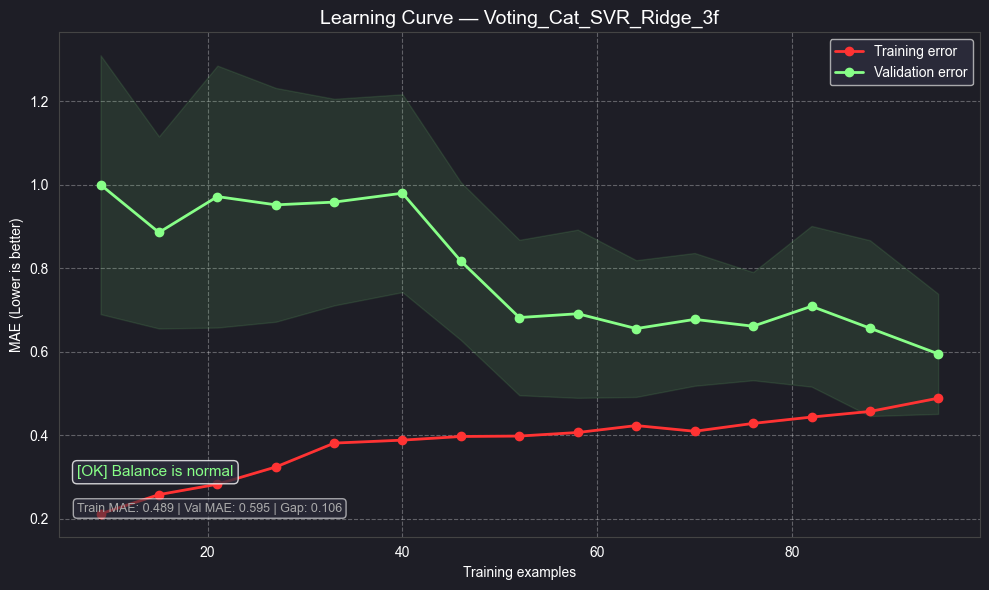

,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
0,ExtraTrees_3f,0.738120,-0.123861,0.274344,1.080586,0.205188
4,ElasticNet_Ensemble_3f,0.761200,-0.230657,0.210452,1.137935,0.014804
6,Voting_Cat_SVR_Ridge_3f,0.602253,0.126801,0.079141,1.294072,-0.082330
7,CatBoost_3f,0.666750,0.049951,0.216418,1.260956,-0.166647
5,Voting_Cat_SVR_3f,0.664488,0.018920,0.081176,1.380074,-0.275532
10,HuberSVR_3f,0.582460,0.267194,0.073985,1.483056,-0.326495
3,KNN_3f,0.621821,0.195105,0.074770,1.315813,-0.373335
1,BayesianRidge_3f,0.638871,0.023599,0.067361,1.378718,-0.433478
9,SVR_3f,0.619363,-0.021277,0.113323,1.348611,-0.448730
8,Ridge_3f,0.622587,0.037926,0.088205,1.401741,-0.481175


📐 Fold sizes:
   Fold 1: train=95 days, test=14 days
   Fold 2: train=109 days, test=14 days
   Fold 3: train=123 days, test=14 days

📊 Naive baseline (assuming lag_1):
   Lag-1 R²=-2.543, MAE=1.727

⏳ ExtraTrees_4f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'interest_delta_5d', 'had_severe_bad_sleep_last_2d', 'had_severe_sleep_last_2d']
   CV R² by folds: [-0.138  0.362 -0.468]

⏳ BayesianRidge_4f...
   ✅ Features: ['had_severe_bad_joy_last_2d', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'sleep_lag_7_corr_0.285']
   CV R² by folds: [-0.056 -0.013  0.162]

⏳ SVR_linear_4f...
   ✅ Features: ['target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [ 0.042 -0.143  0.114]

⏳ KNN_4f...
   ✅ Features: ['target_final_lag_4_corr_0.301', 'irritation_delta_2d', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [0.273 0.313 0.213]

⏳ ElasticNet_Ensemble_4f...
   ✅ Features

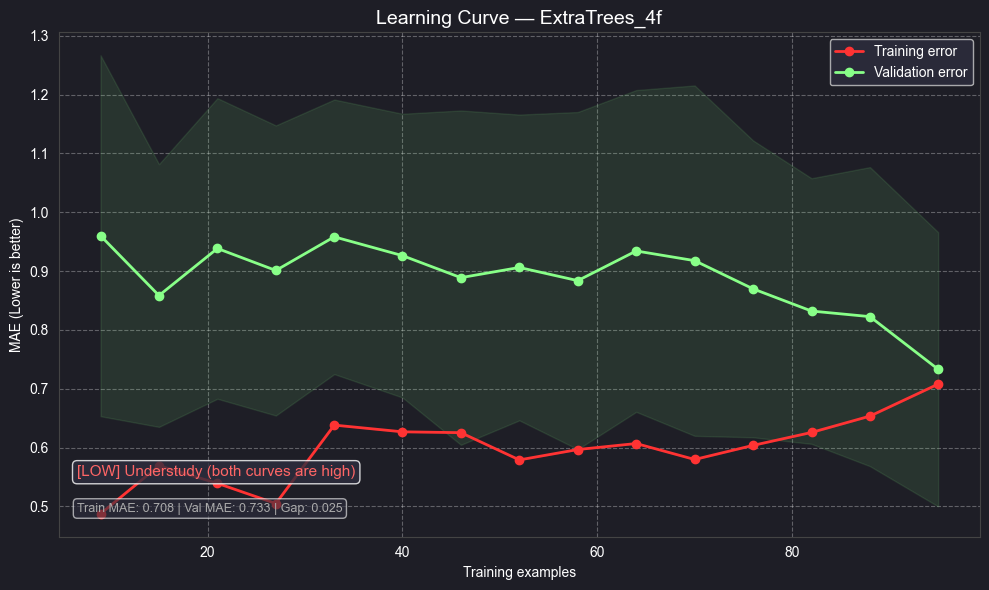


📈 Building a learning curve for: Voting_Cat_SVR_Ridge_4f


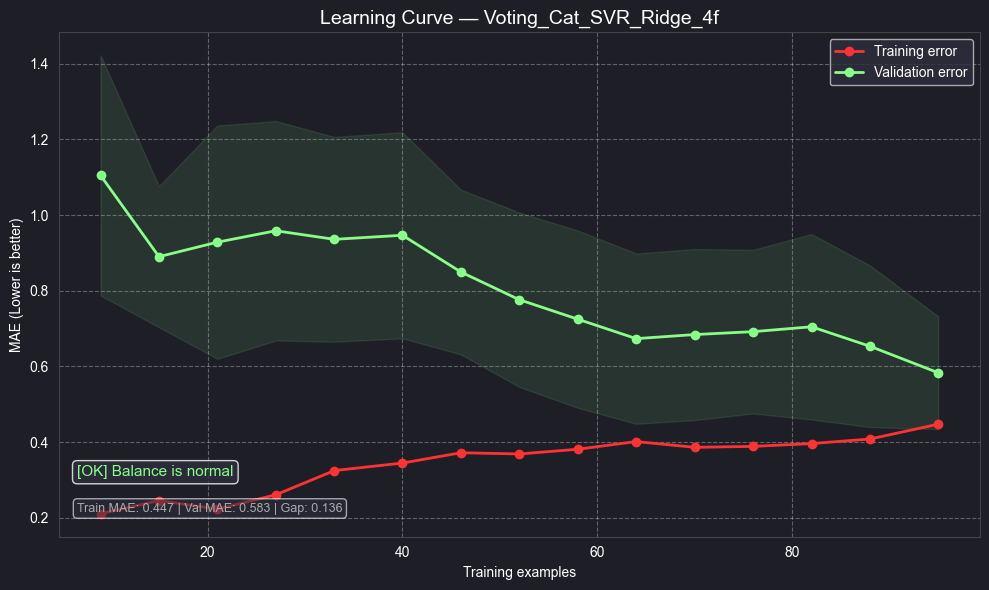


📈 Building a learning curve for: Voting_Cat_SVR_4f


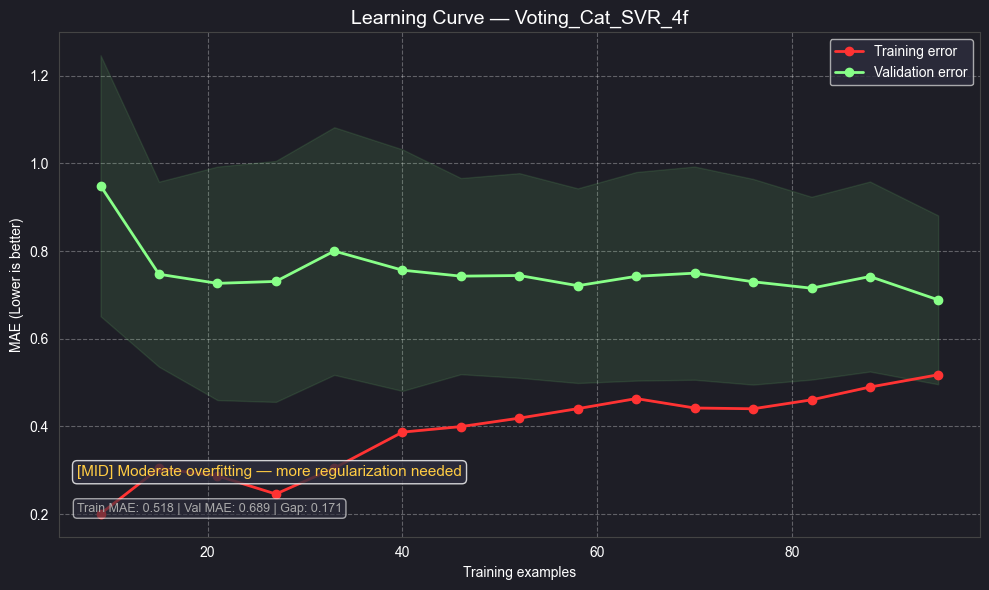


📈 Building a learning curve for: CatBoost_4f


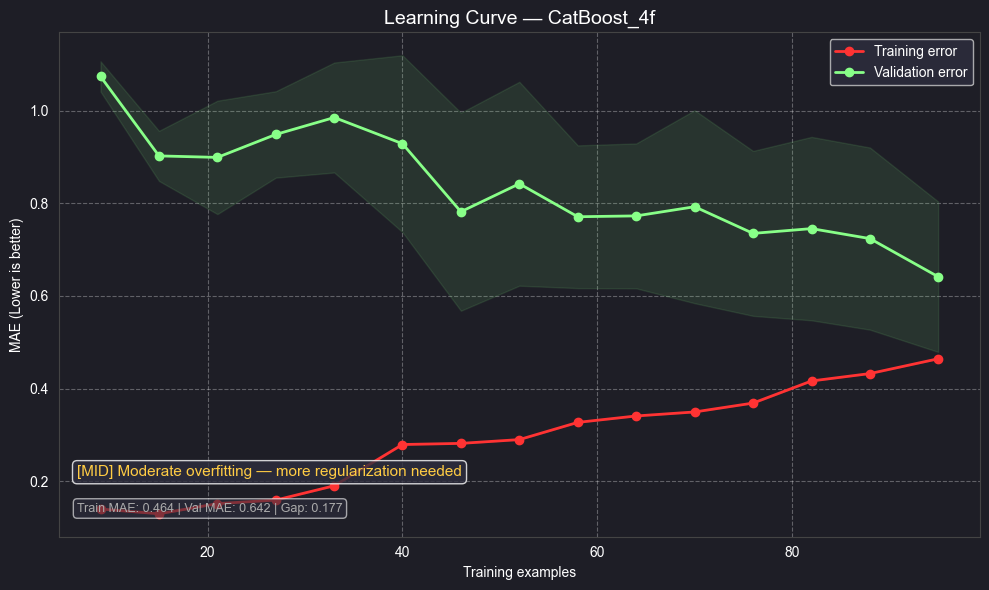

,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
0,ExtraTrees_4f,0.736088,-0.081089,0.341242,1.074751,0.181941
6,Voting_Cat_SVR_Ridge_4f,0.567410,0.220283,0.055263,1.247911,-0.004504
4,ElasticNet_Ensemble_4f,0.737639,-0.188730,0.255039,1.121293,-0.005472
5,Voting_Cat_SVR_4f,0.628805,0.139239,0.101761,1.202371,-0.021735
7,CatBoost_4f,0.621570,0.134894,0.163685,1.217165,-0.034258
10,HuberSVR_4f,0.597762,0.187608,0.053075,1.345339,-0.188403
3,KNN_4f,0.600919,0.266450,0.041446,1.369849,-0.342446
2,SVR_linear_4f,0.662210,0.004318,0.108024,1.343368,-0.413154
1,BayesianRidge_4f,0.649787,0.030761,0.094134,1.379257,-0.429775
8,Ridge_4f,0.649911,0.035071,0.110315,1.400668,-0.474534


📐 Fold sizes:
   Fold 1: train=95 days, test=14 days
   Fold 2: train=109 days, test=14 days
   Fold 3: train=123 days, test=14 days

📊 Naive baseline (assuming lag_1):
   Lag-1 R²=-2.543, MAE=1.727

⏳ ExtraTrees_5f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'interest_delta_5d', 'energy_lag_4_corr_0.297', 'had_severe_bad_sleep_last_2d', 'had_severe_sleep_last_2d']
   CV R² by folds: [-0.035  0.311 -0.34 ]

⏳ BayesianRidge_5f...
   ✅ Features: ['had_severe_bad_joy_last_2d', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285']
   CV R² by folds: [-0.041  0.011  0.077]

⏳ SVR_linear_5f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [-0.003  0.016 -0.053]

⏳ KNN_5f...
   ✅ Features: ['target_final_lag_4_corr_0.301', 'irritation_delta_2d', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291

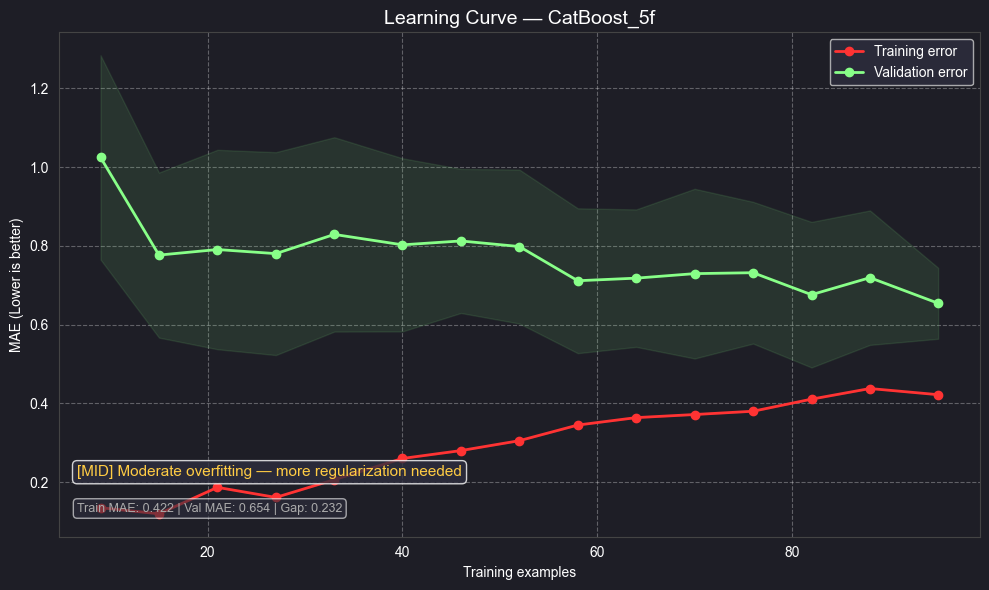


📈 Building a learning curve for: ExtraTrees_5f


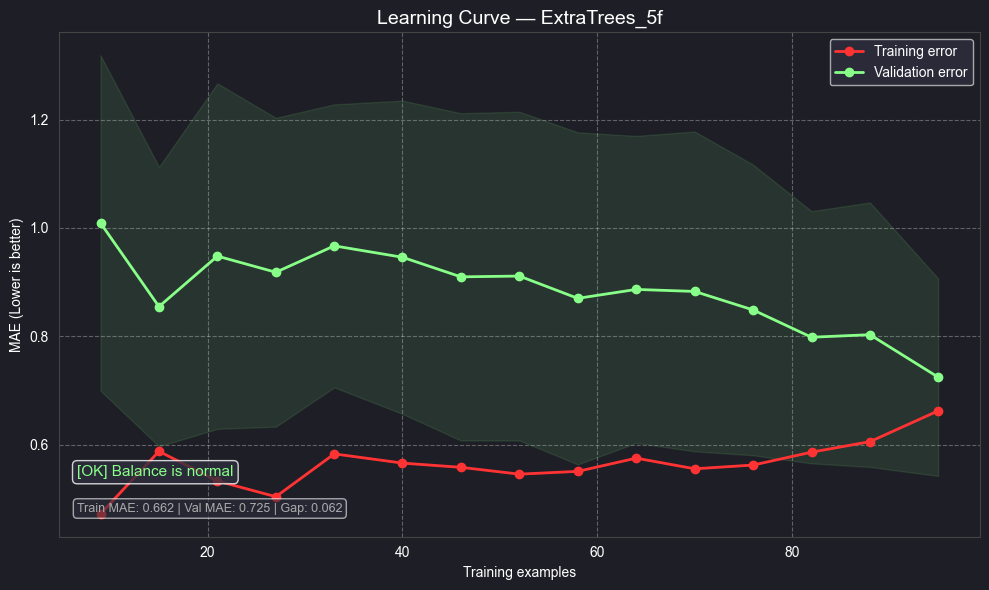


📈 Building a learning curve for: Voting_Cat_SVR_5f


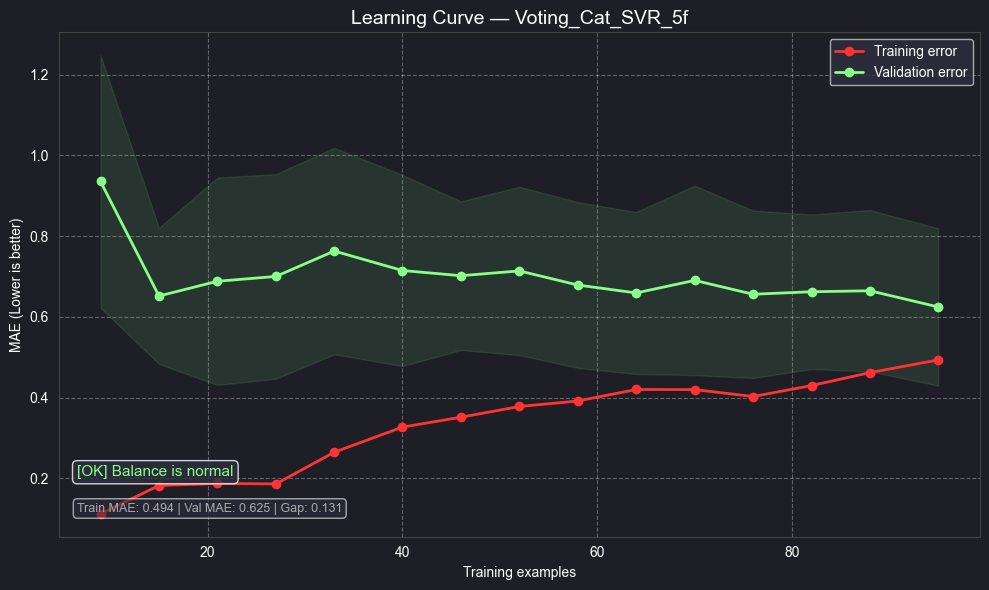


📈 Building a learning curve for: SVR_linear_5f


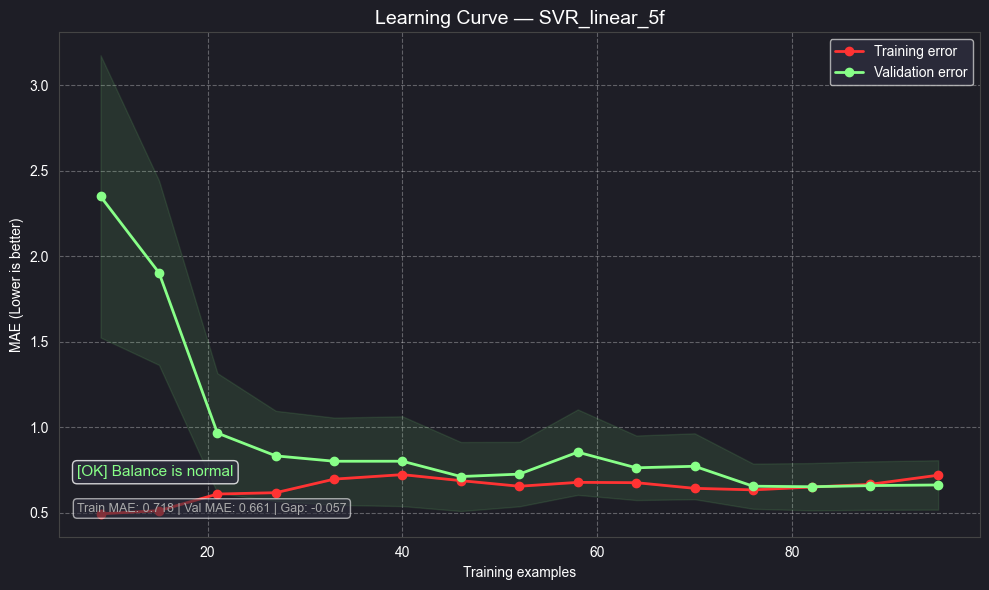

,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
7,CatBoost_5f,0.604446,0.150662,0.065385,1.104455,0.106229
0,ExtraTrees_5f,0.717661,-0.021277,0.265923,1.159328,0.037353
5,Voting_Cat_SVR_5f,0.605816,0.170788,0.163988,1.202385,-0.036141
2,SVR_linear_5f,0.645793,-0.013263,0.029313,1.205244,-0.054235
6,Voting_Cat_SVR_Ridge_5f,0.536511,0.297281,0.036617,1.323646,-0.135725
4,ElasticNet_Ensemble_5f,0.708973,-0.111641,0.205884,1.221488,-0.173702
1,BayesianRidge_5f,0.640907,0.015698,0.048319,1.341637,-0.376879
8,Ridge_5f,0.637776,0.021631,0.057023,1.361991,-0.420139
9,SVR_5f,0.614532,0.004295,0.227344,1.379768,-0.490990
10,HuberSVR_5f,0.625040,0.124721,0.211068,1.457026,-0.491937


📐 Fold sizes:
   Fold 1: train=95 days, test=14 days
   Fold 2: train=109 days, test=14 days
   Fold 3: train=123 days, test=14 days

📊 Naive baseline (assuming lag_1):
   Lag-1 R²=-2.543, MAE=1.727

⏳ ExtraTrees_6f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'interest_delta_5d', 'energy_lag_4_corr_0.297', 'had_severe_bad_sleep_last_2d', 'had_severe_sleep_last_2d', 'had_not_fatigue_last_2d']
   CV R² by folds: [ 0.     0.431 -0.227]

⏳ BayesianRidge_6f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'had_severe_bad_joy_last_2d', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285']
   CV R² by folds: [-0.043  0.059 -0.032]

⏳ SVR_linear_6f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [ 0.071 -0.053 -0.081]

⏳ KNN_6f...
   ✅ Features: ['target_final_lag_4_corr

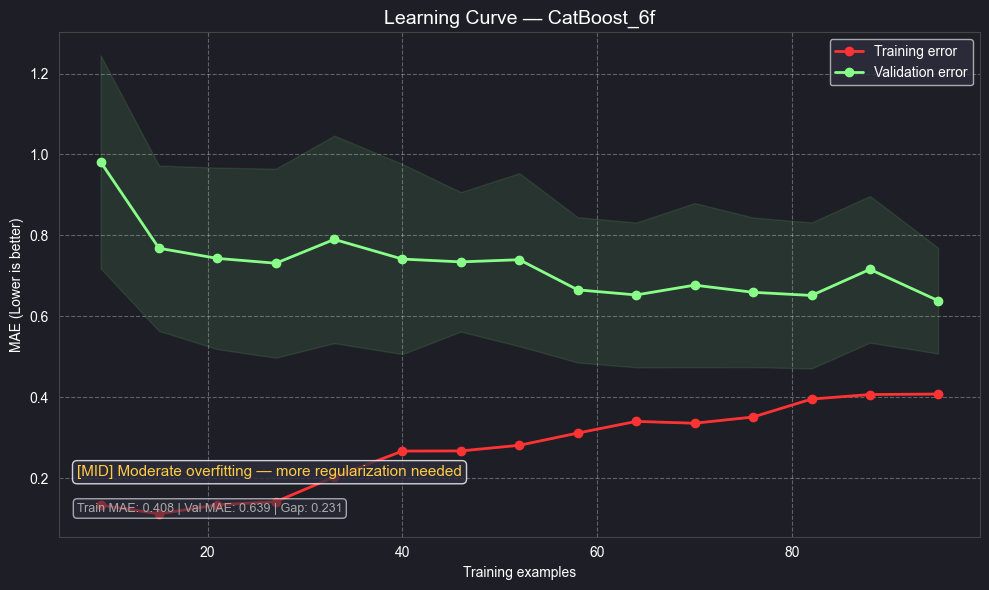


📈 Building a learning curve for: Voting_Cat_SVR_Ridge_6f


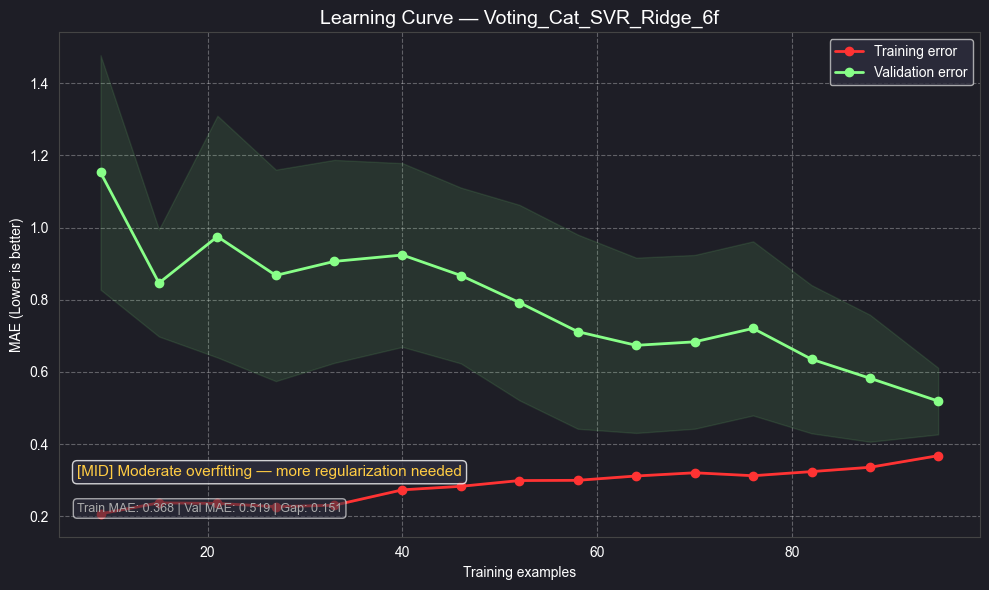

,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
7,CatBoost_6f,0.613870,0.194287,0.030804,1.202347,0.011484
6,Voting_Cat_SVR_Ridge_6f,0.519727,0.314485,0.110322,1.300469,-0.096433
2,SVR_linear_6f,0.624783,-0.021141,0.066220,1.259988,-0.149195
0,ExtraTrees_6f,0.692219,0.068200,0.272608,1.268909,-0.151837
1,BayesianRidge_6f,0.656992,-0.005182,0.045709,1.228604,-0.160065
5,Voting_Cat_SVR_6f,0.633891,0.207885,0.189105,1.299754,-0.212287
10,HuberSVR_6f,0.653817,0.077866,0.158767,1.302158,-0.225904
4,ElasticNet_Ensemble_6f,0.677989,-0.128736,0.251601,1.272819,-0.281850
9,SVR_6f,0.613392,0.080361,0.140282,1.280095,-0.298500
8,Ridge_6f,0.653521,-0.006400,0.082893,1.377881,-0.454967


📐 Fold sizes:
   Fold 1: train=95 days, test=14 days
   Fold 2: train=109 days, test=14 days
   Fold 3: train=123 days, test=14 days

📊 Naive baseline (assuming lag_1):
   Lag-1 R²=-2.543, MAE=1.727

⏳ ExtraTrees_7f...
⏩ Skipping ExtraTrees for 7 features (risk of overfitting)

⏳ BayesianRidge_7f...
   ✅ Features: ['target_final_lag_1_corr_0.383', 'had_severe_bad_joy_last_2d', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [-0.07   0.053 -0.05 ]

⏳ SVR_linear_7f...
   ✅ Features: ['fatigue_ewm_9_corr_-0.383', 'target_final_lag_1_corr_0.383', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [-0.078  0.087 -0.04 ]

⏳ KNN_7f...
⏩ Skipping KNN for 7 features (risk of overfitting)

⏳ ElasticNet_Ensemble_7f...
   ✅ Features: ['week_of_year', 'energy_lag_1_corr_0.377', 'target_f

,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
4,SVR_7f,0.636673,0.033015,0.116512,1.218979,-0.153411
0,BayesianRidge_7f,0.665573,-0.022241,0.053638,1.223018,-0.155131
2,ElasticNet_Ensemble_7f,0.714052,-0.137457,0.216334,1.234481,-0.175112
3,Ridge_7f,0.648696,0.008019,0.022764,1.241603,-0.179506
1,SVR_linear_7f,0.654886,-0.010513,0.070696,1.251767,-0.194935
5,HuberSVR_7f,0.673182,0.083144,0.106805,1.297690,-0.307154


📐 Fold sizes:
   Fold 1: train=95 days, test=14 days
   Fold 2: train=109 days, test=14 days
   Fold 3: train=123 days, test=14 days

📊 Naive baseline (assuming lag_1):
   Lag-1 R²=-2.543, MAE=1.727

⏳ ExtraTrees_8f...
⏩ Skipping ExtraTrees for 8 features (risk of overfitting)

⏳ BayesianRidge_8f...
   ✅ Features: ['fatigue_ewm_9_corr_-0.383', 'target_final_lag_1_corr_0.383', 'had_severe_bad_joy_last_2d', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [-0.097  0.102 -0.129]

⏳ SVR_linear_8f...
   ✅ Features: ['fatigue_ewm_9_corr_-0.383', 'target_final_lag_1_corr_0.383', 'mood_weekly_context', 'target_final_lag_4_corr_0.301', 'calm_sma_9d_corr_0.323', 'joy_x_anxiety_roll_2', 'sleep_lag_7_corr_0.285', 'interest_lag_1_corr_0.291']
   CV R² by folds: [ 0.041  0.045 -0.091]

⏳ KNN_8f...
⏩ Skipping KNN for 8 features (risk of overfitting)

⏳ ElasticNet_Ensemble_8f...
   ✅ Features: [

,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
1,SVR_linear_8f,0.615438,-0.001934,0.062968,1.226427,-0.118790
0,BayesianRidge_8f,0.678617,-0.041125,0.102147,1.217868,-0.145092
2,ElasticNet_Ensemble_8f,0.714601,-0.158718,0.231645,1.230604,-0.170628
3,Ridge_8f,0.652834,0.000877,0.027320,1.240732,-0.181606
5,HuberSVR_8f,0.665037,0.052369,0.112900,1.269883,-0.196057
4,SVR_8f,0.666805,0.037042,0.163148,1.231494,-0.404570



🎯 Passed the filter (11 models): ['CatBoost_6f', 'Voting_Cat_SVR_Ridge_4f', 'Voting_Cat_SVR_Ridge_6f', 'CatBoost_5f', 'Voting_Cat_SVR_Ridge_3f', 'Voting_Cat_SVR_4f', 'SVR_linear_5f', 'Voting_Cat_SVR_5f', 'CatBoost_4f', 'ExtraTrees_5f', 'ExtraTrees_4f']

🔬 Fine-tune: CatBoost_6f (features: 6)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
   CV R² by folds: [0.202 0.217 0.141]
   TEST R²=0.008  TEST MAE=1.210
   Best params: {'model__subsample': 0.8, 'model__random_strength': 10, 'model__min_data_in_leaf': 10, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 1, 'model__iterations': 400, 'model__depth': 3, 'model__bootstrap_type': 'Bernoulli'}


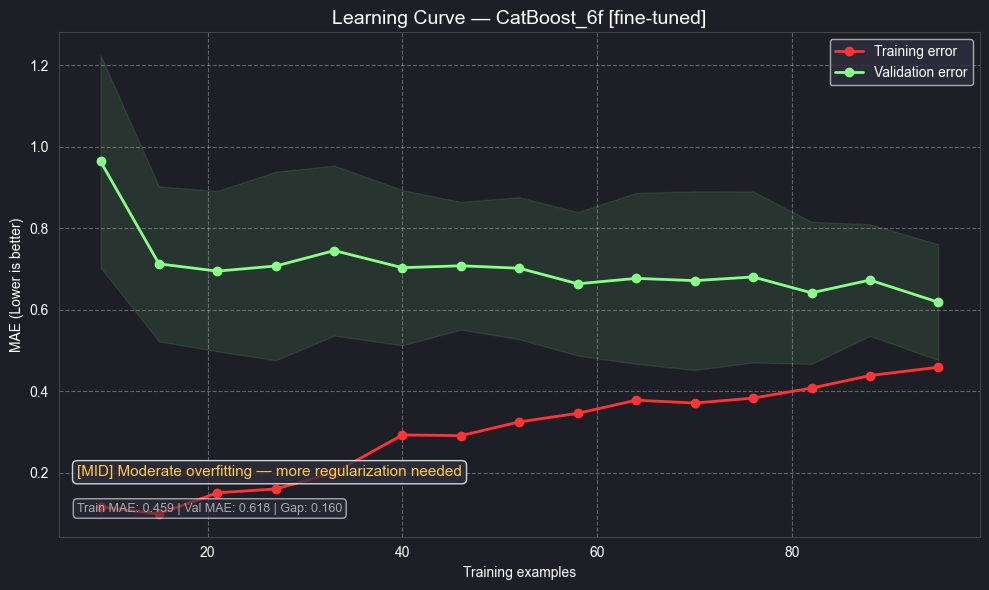


🔬 Fine-tune: Voting_Cat_SVR_Ridge_4f (features: 4)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
   CV R² by folds: [0.279 0.303 0.178]
   TEST R²=0.007  TEST MAE=1.236
   Best params: {'model__svr__C': 15, 'model__ridge__alpha': 10.0, 'model__catboost__depth': 4}


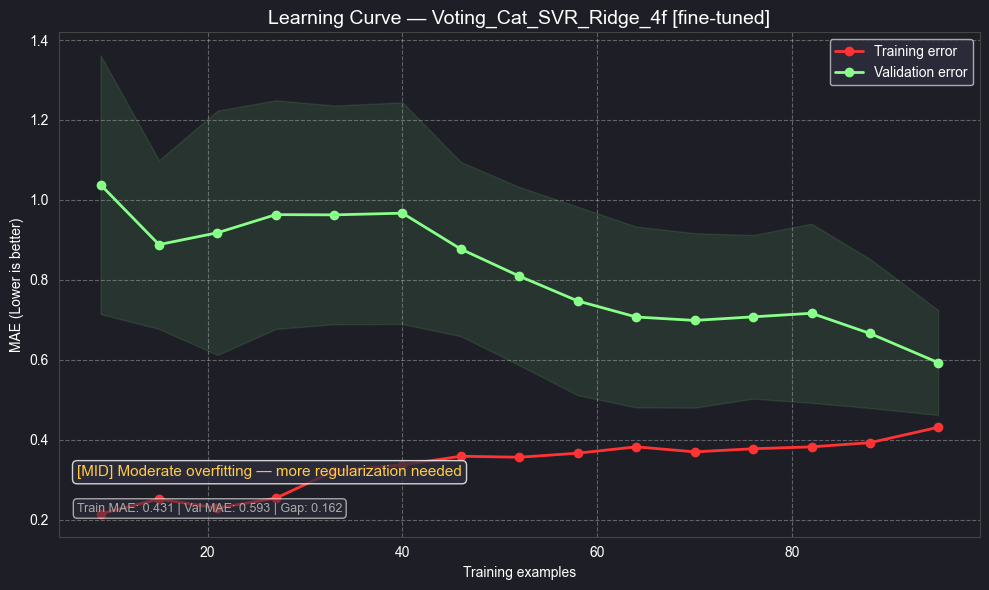


🔬 Fine-tune: Voting_Cat_SVR_Ridge_6f (features: 6)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
   CV R² by folds: [0.391 0.404 0.192]
   TEST R²=-0.073  TEST MAE=1.283
   Best params: {'model__svr__C': 15, 'model__ridge__alpha': 10.0, 'model__catboost__depth': 4}


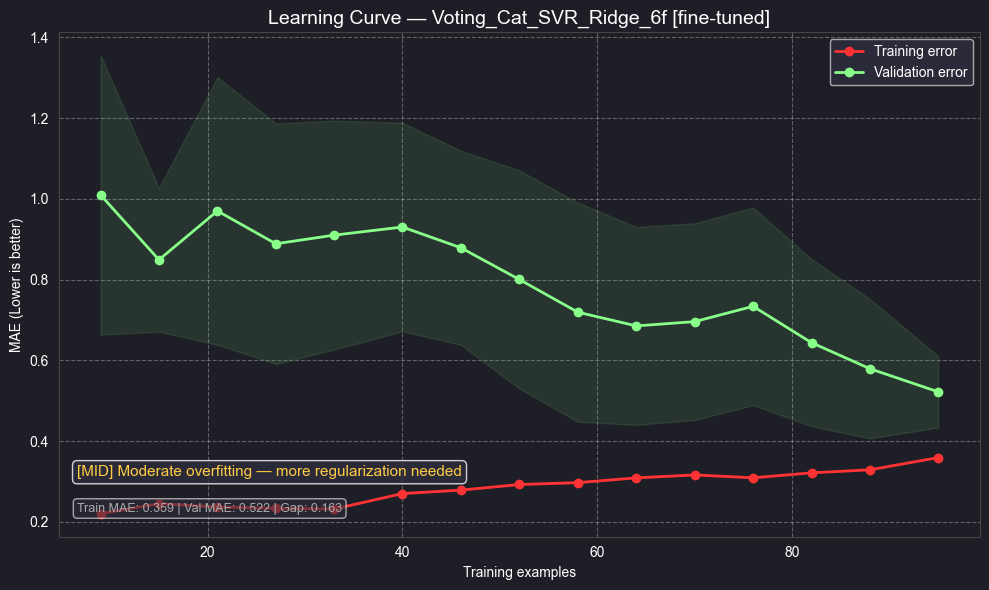


🔬 Fine-tune: CatBoost_5f (features: 5)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
   CV R² by folds: [ 0.23   0.291 -0.06 ]
   TEST R²=0.131  TEST MAE=1.095
   Best params: {'model__subsample': 0.8, 'model__random_strength': 10, 'model__min_data_in_leaf': 10, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 1, 'model__iterations': 400, 'model__depth': 3, 'model__bootstrap_type': 'Bernoulli'}


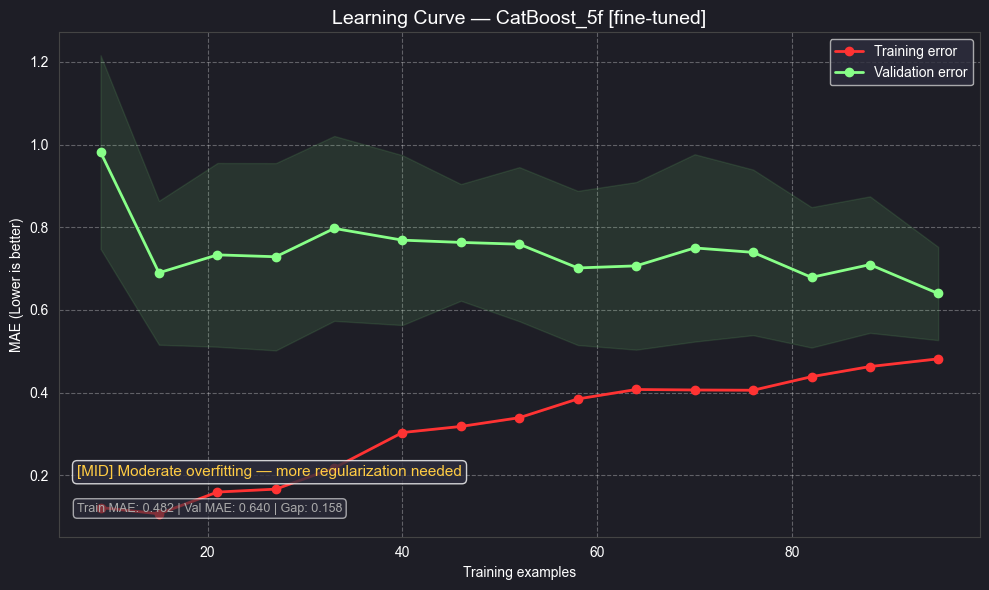


🔬 Fine-tune: Voting_Cat_SVR_Ridge_3f (features: 3)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
   CV R² by folds: [0.018 0.143 0.239]
   TEST R²=-0.098  TEST MAE=1.307
   Best params: {'model__svr__C': 15, 'model__ridge__alpha': 10.0, 'model__catboost__depth': 4}


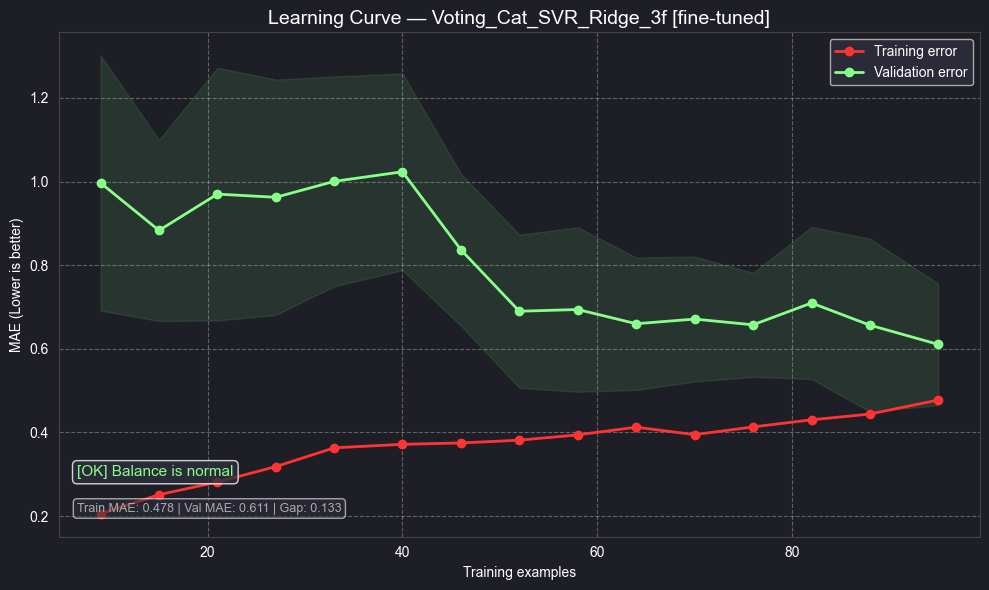


🔬 Fine-tune: Voting_Cat_SVR_4f (features: 4)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
   CV R² by folds: [0.006 0.117 0.192]
   TEST R²=0.014  TEST MAE=1.183
   Best params: {'model__svr__epsilon': 0.1, 'model__svr__C': 1, 'model__catboost__depth': 3}


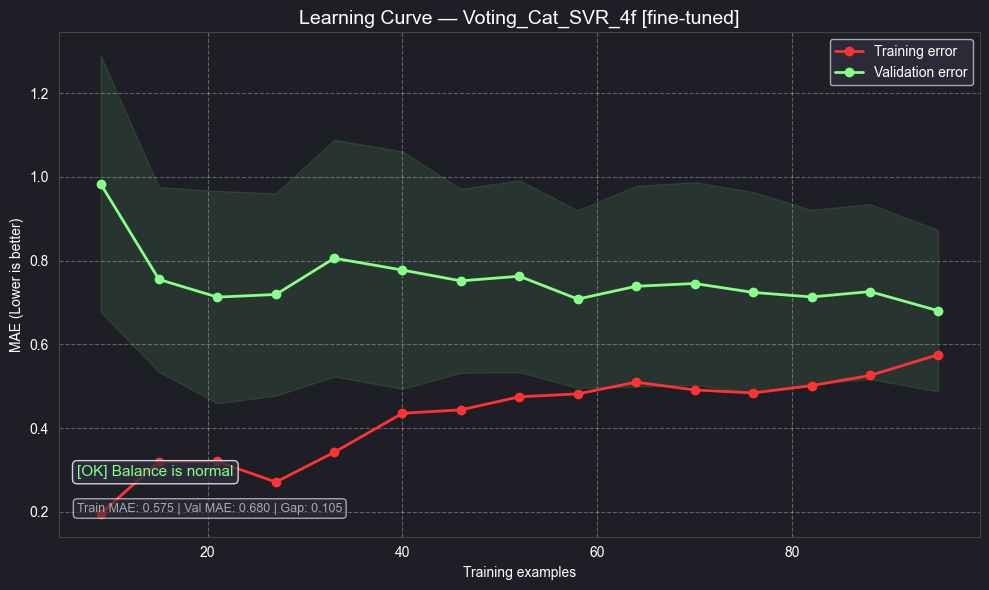


🔬 Fine-tune: SVR_linear_5f (features: 5)
Fitting 3 folds for each of 15 candidates, totalling 45 fits
   CV R² by folds: [-0.055  0.     0.045]
   TEST R²=-0.176  TEST MAE=1.229
   Best params: {'model__epsilon': 0.5, 'model__C': 0.1}


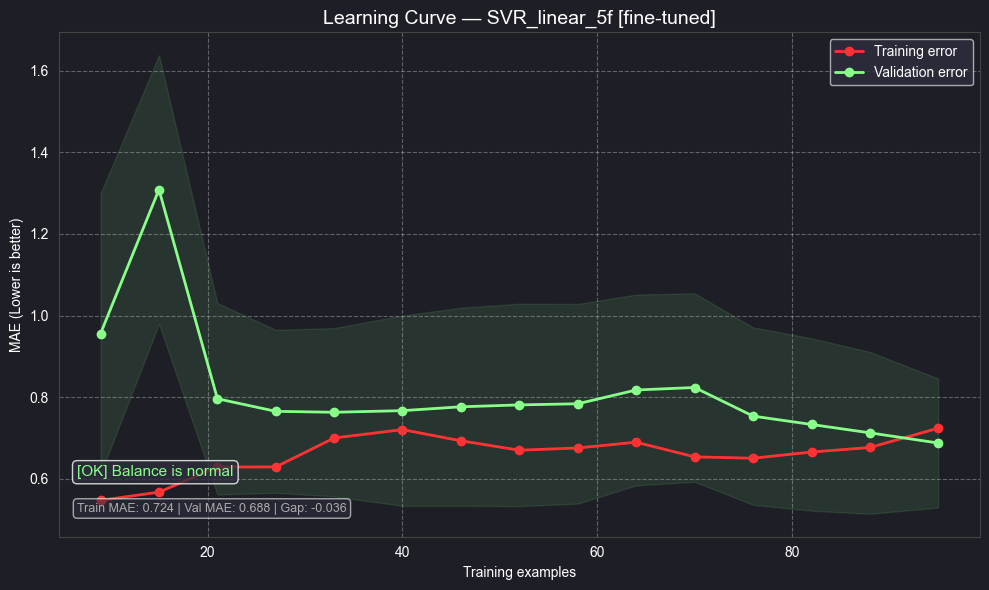


🔬 Fine-tune: Voting_Cat_SVR_5f (features: 5)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
   CV R² by folds: [-0.011  0.095  0.378]
   TEST R²=-0.030  TEST MAE=1.207
   Best params: {'model__svr__epsilon': 0.1, 'model__svr__C': 1, 'model__catboost__depth': 3}


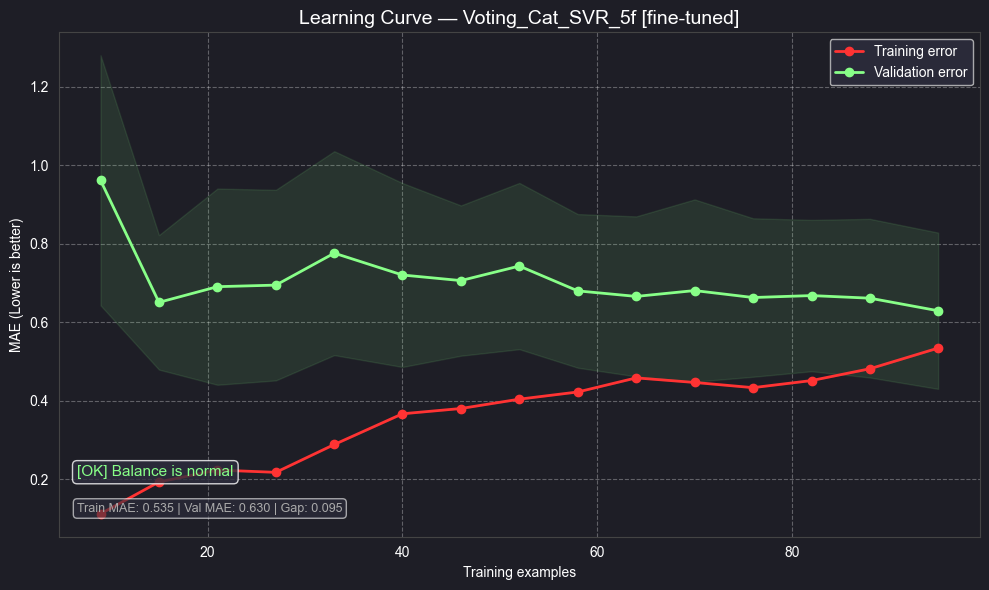


🔬 Fine-tune: CatBoost_4f (features: 4)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
   CV R² by folds: [ 0.123  0.318 -0.149]
   TEST R²=-0.050  TEST MAE=1.242
   Best params: {'model__subsample': 0.8, 'model__random_strength': 5, 'model__min_data_in_leaf': 5, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 10, 'model__iterations': 500, 'model__depth': 4, 'model__bootstrap_type': 'Bernoulli'}


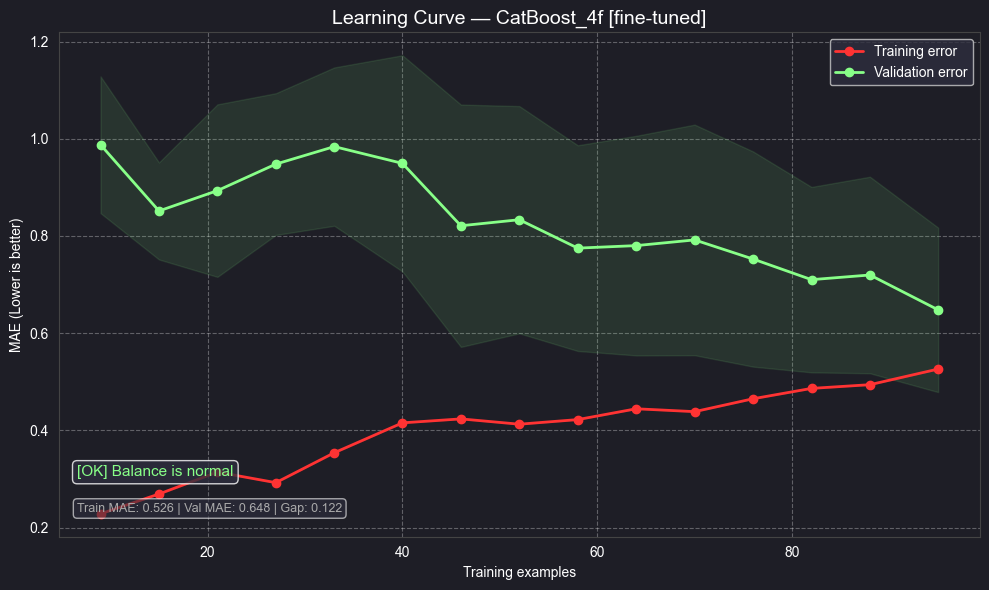


🔬 Fine-tune: ExtraTrees_5f (features: 5)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
   CV R² by folds: [-0.204  0.248 -0.376]
   TEST R²=-0.088  TEST MAE=1.221
   Best params: {'model__n_estimators': 50, 'model__min_samples_leaf': 5, 'model__max_depth': 3}


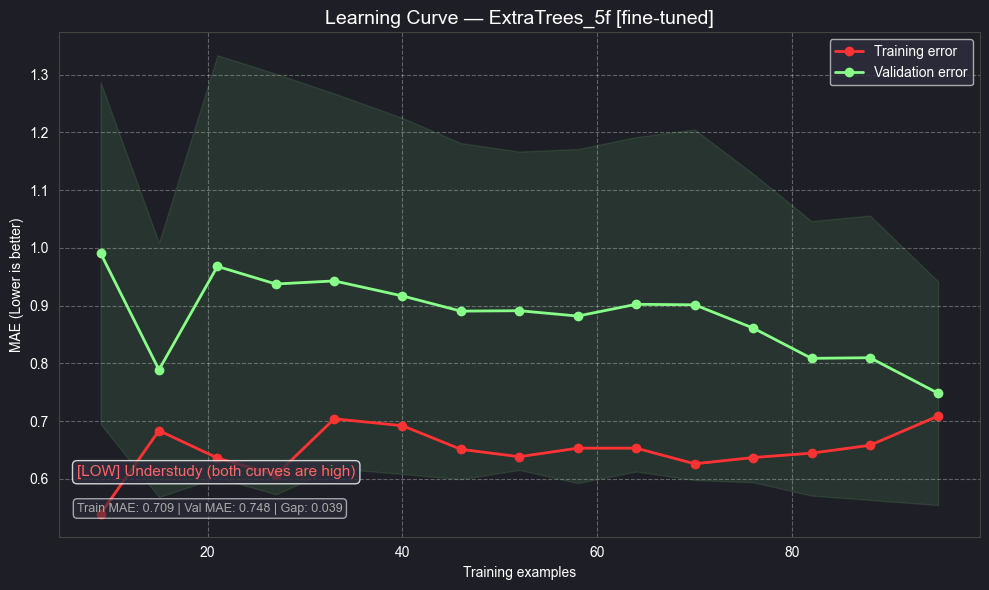


🔬 Fine-tune: ExtraTrees_4f (features: 4)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
   CV R² by folds: [-0.335  0.34  -0.544]
   TEST R²=0.041  TEST MAE=1.157
   Best params: {'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 3}


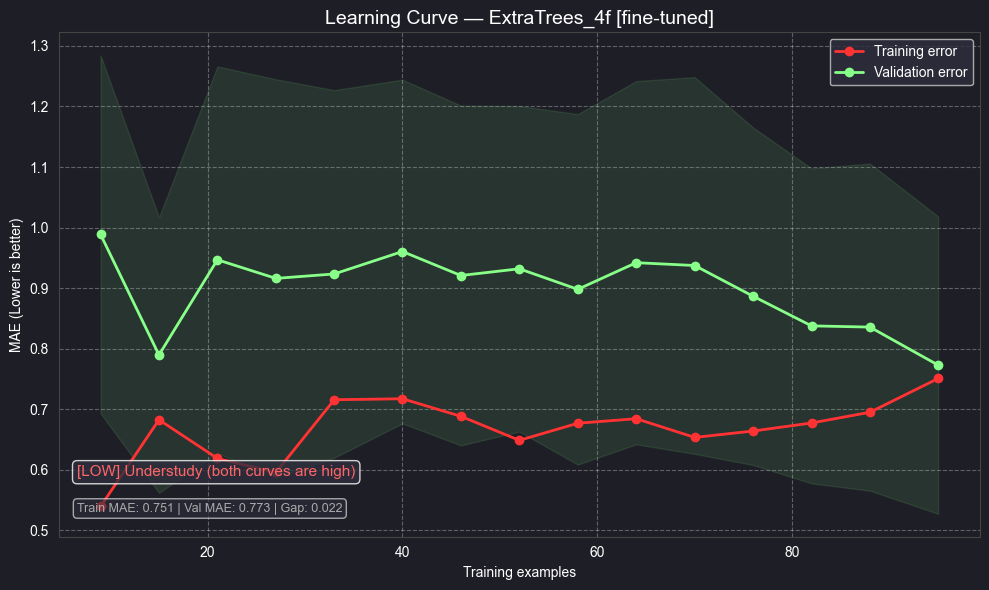


📊 Fine-tune results:
                           Model    CV MAE     CV R2  CV R2 Std  \
2   Voting_Cat_SVR_Ridge_6f [FT]  0.520038  0.328630   0.097103   
1   Voting_Cat_SVR_Ridge_4f [FT]  0.552244  0.253366   0.053829   
0               CatBoost_6f [FT]  0.601018  0.186592   0.033116   
7         Voting_Cat_SVR_5f [FT]  0.618054  0.154099   0.164123   
3               CatBoost_5f [FT]  0.619192  0.153735   0.153061   
4   Voting_Cat_SVR_Ridge_3f [FT]  0.600645  0.133542   0.090736   
5         Voting_Cat_SVR_4f [FT]  0.646347  0.104830   0.076418   
8               CatBoost_4f [FT]  0.634767  0.097558   0.191464   
6             SVR_linear_5f [FT]  0.655519 -0.003481   0.040887   
9             ExtraTrees_5f [FT]  0.741904 -0.110509   0.263117   
10            ExtraTrees_4f [FT]  0.755665 -0.179472   0.376987   

    TEST MAE (14d)  TEST R2 (14d)  
2         1.283318      -0.073382  
1         1.236043       0.006884  
0         1.210361       0.008154  
7         1.206907      -0.03

In [42]:
# ---------------------------------------------------------------------------
# LAUNCHING
# ---------------------------------------------------------------------------

all_results = []
all_pipes = {}

for n_feat in [3, 4, 5, 6, 7, 8]:
    results, pipes = compare_models_with_sfs(
        X_train_filtered,
        X_test_filtered,
        y_train,
        y_test,
        n_features=n_feat,
    )
    all_pipes.update(pipes)
    print("\n" + "=" * 80)
    display(results[["Model", "CV MAE", "CV R2", "CV R2 Std", "TEST MAE (14d)", "TEST R2 (14d)"]])
    all_results.append(results)

combined = pd.concat(all_results).sort_values(
    by=["TEST R2 (14d)", "CV R2"],
    ascending=[False, False],
)

ft_results = finetune_best_models(
    combined,
    all_pipes,
    X_train_filtered,
    X_test_filtered,
    y_train,
    y_test,
)

### 9.9 Results Summary & Feature Analysis

📊 Pre-finetune — all configurations:


,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
0,ExtraTrees_3f,0.738120,-0.123861,0.274344,1.080586,0.205188
1,ExtraTrees_4f,0.736088,-0.081089,0.341242,1.074751,0.181941
2,CatBoost_5f,0.604446,0.150662,0.065385,1.104455,0.106229
3,ExtraTrees_5f,0.717661,-0.021277,0.265923,1.159328,0.037353
4,ElasticNet_Ensemble_3f,0.761200,-0.230657,0.210452,1.137935,0.014804
5,CatBoost_6f,0.613870,0.194287,0.030804,1.202347,0.011484
6,Voting_Cat_SVR_Ridge_4f,0.567410,0.220283,0.055263,1.247911,-0.004504
7,ElasticNet_Ensemble_4f,0.737639,-0.188730,0.255039,1.121293,-0.005472
8,Voting_Cat_SVR_4f,0.628805,0.139239,0.101761,1.202371,-0.021735
9,CatBoost_4f,0.621570,0.134894,0.163685,1.217165,-0.034258



📊 Fine-tuned — all configurations:


,Model,CV MAE,CV R2,CV R2 Std,TEST MAE (14d),TEST R2 (14d)
0,Voting_Cat_SVR_Ridge_6f [FT],0.520038,0.328630,0.097103,1.283318,-0.073382
1,Voting_Cat_SVR_Ridge_4f [FT],0.552244,0.253366,0.053829,1.236043,0.006884
2,CatBoost_6f [FT],0.601018,0.186592,0.033116,1.210361,0.008154
3,Voting_Cat_SVR_5f [FT],0.618054,0.154099,0.164123,1.206907,-0.030049
4,CatBoost_5f [FT],0.619192,0.153735,0.153061,1.094628,0.130504
5,Voting_Cat_SVR_Ridge_3f [FT],0.600645,0.133542,0.090736,1.307456,-0.097680
6,Voting_Cat_SVR_4f [FT],0.646347,0.104830,0.076418,1.182762,0.014097
7,CatBoost_4f [FT],0.634767,0.097558,0.191464,1.241606,-0.050020
8,SVR_linear_5f [FT],0.655519,-0.003481,0.040887,1.228864,-0.176342
9,ExtraTrees_5f [FT],0.741904,-0.110509,0.263117,1.221230,-0.088029


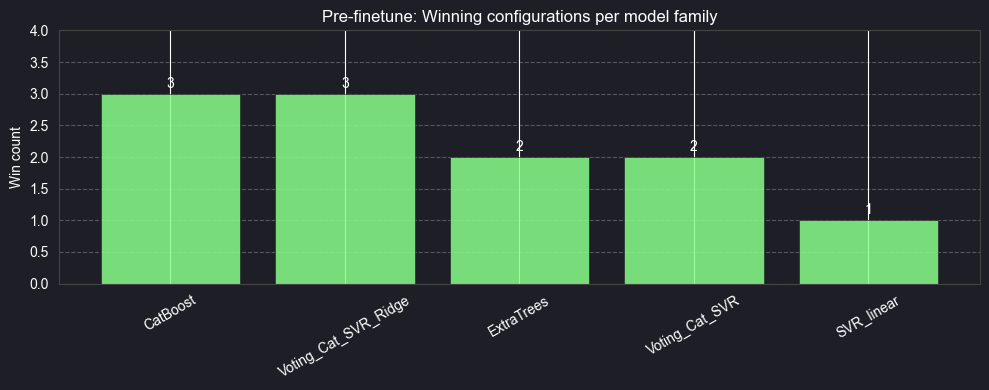

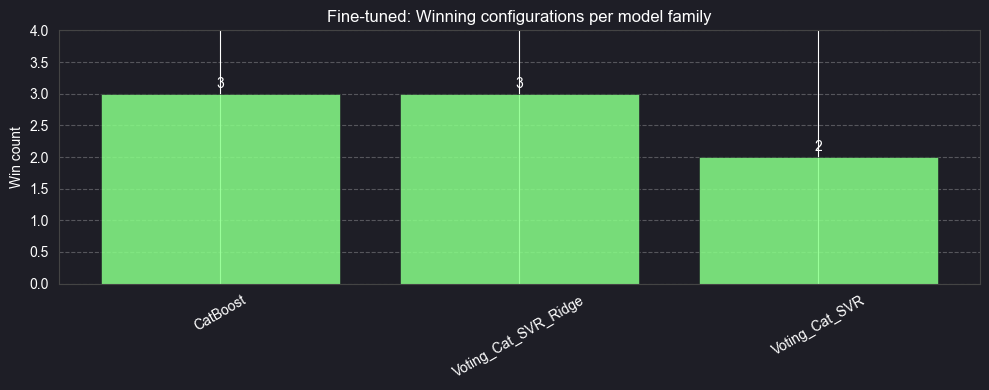

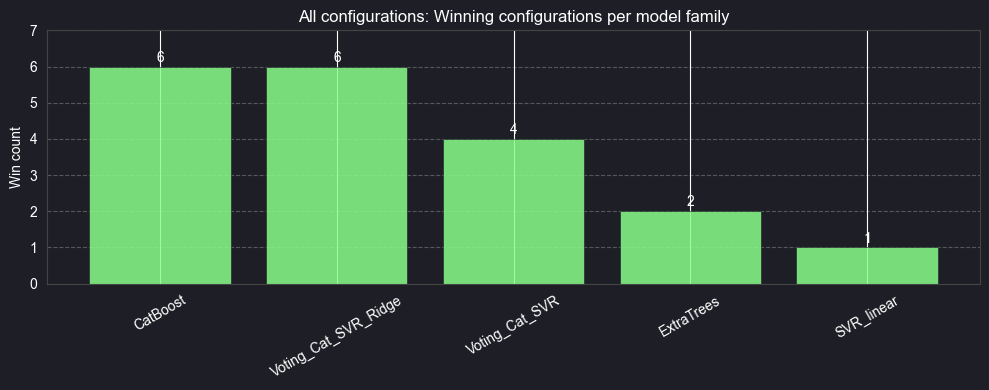


🔝 Top features in successful models:


,Feature,Count,Models
0,target_final_lag_1_corr_0.383,11,"ExtraTrees_4f, CatBoost_5f, ExtraTrees_5f, Cat..."
1,interest_delta_5d,7,"ExtraTrees_4f, CatBoost_5f, ExtraTrees_5f, Cat..."
2,joy_delta_1d,5,"CatBoost_5f, CatBoost_6f, Voting_Cat_SVR_4f, V..."
3,calm_lag_5_corr_0.173,4,"CatBoost_5f, CatBoost_6f, CatBoost_4f, Voting_..."
4,sleep_lag_7_corr_0.285,4,"Voting_Cat_SVR_Ridge_4f, SVR_linear_5f, Voting..."
5,target_final_lag_4_corr_0.301,4,"Voting_Cat_SVR_Ridge_4f, SVR_linear_5f, Voting..."
6,fatigue_lag_2_corr_-0.239,3,"CatBoost_5f, CatBoost_6f, CatBoost_4f"
7,sleep_lag_5_corr_0.225,3,"CatBoost_6f, Voting_Cat_SVR_4f, Voting_Cat_SVR_5f"
8,had_severe_bad_sleep_last_2d,2,"ExtraTrees_4f, ExtraTrees_5f"
9,had_severe_sleep_last_2d,2,"ExtraTrees_4f, ExtraTrees_5f"


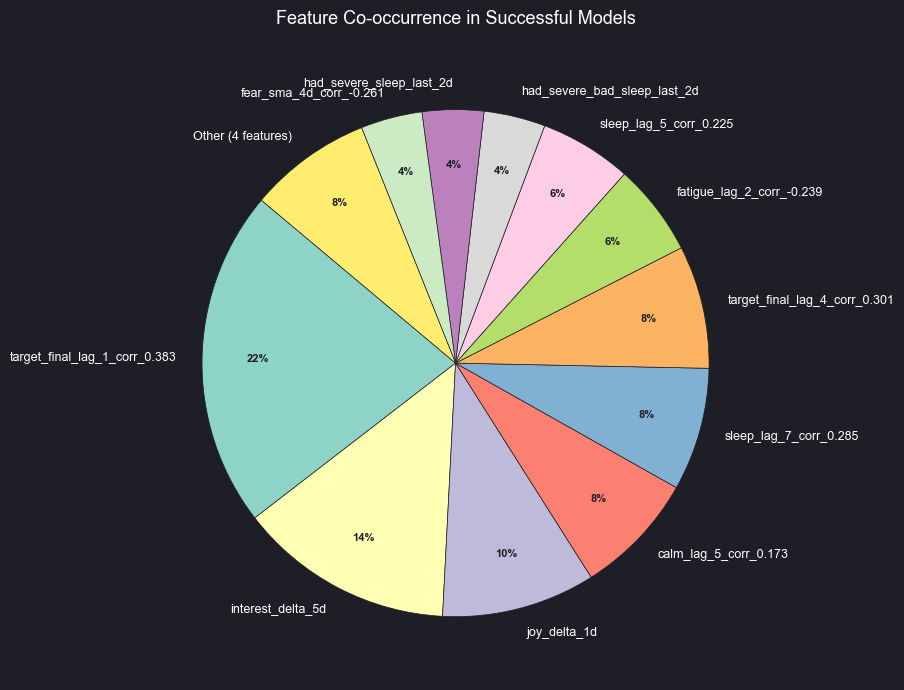

Naive baseline on TEST: MAE=1.857, R²=-1.681


In [43]:
# ---------------------------------------------------------------------------
# Summary tables
# ---------------------------------------------------------------------------

print("📊 Pre-finetune — all configurations:")
display(
    combined[
        ["Model", "CV MAE", "CV R2", "CV R2 Std", "TEST MAE (14d)", "TEST R2 (14d)"]
    ].reset_index(drop=True)
)

print("\n📊 Fine-tuned — all configurations:")
display(
    ft_results[
        ["Model", "CV MAE", "CV R2", "CV R2 Std", "TEST MAE (14d)", "TEST R2 (14d)"]
    ].reset_index(drop=True)
)

# ---------------------------------------------------------------------------
# Model family win-count charts
# ---------------------------------------------------------------------------

plot_model_family_summary(
    pre_df=combined,
    ft_df=ft_results,
    combined_df=pd.concat([combined, ft_results], ignore_index=True),
)

# ---------------------------------------------------------------------------
# Feature co-occurrence across all pre-finetune successful models
# ---------------------------------------------------------------------------

final_feature_stats = analyze_and_plot_selective(combined)

# ---------------------------------------------------------------------------
# Naive baseline reference
# ---------------------------------------------------------------------------

naive_baseline_on_test(X_test_filtered, y_test)

### 9.9 Results & Model Selection
#### Why CatBoost was selected

The full sweep tested **11 model families × 6 feature counts = 66 pre-finetune configurations**, followed by fine-tuning of 11 qualifying candidates — 77 configurations in total.

**Pre-finetune results** revealed that CatBoost appeared in **3 winning configurations** (TEST R² > 0), tied with `Voting_Cat_SVR_Ridge`. However, CatBoost achieved this with lower CV R² Std (0.065 for `CatBoost_5f`) compared to ensemble variants, indicating more consistent generalisation across folds rather than dependence on a single favourable split.

**After fine-tuning**, `CatBoost_5f [FT]` reached the best TEST R² among CatBoost variants (0.131) with CV R² Std of 0.153, while `Voting_Cat_SVR_Ridge` variants — despite higher CV R² — all produced negative TEST R² on the holdout, confirming that their cross-validation scores were optimistic.

**Feature co-occurrence analysis** across all successful models showed that the top-5 most robust signals were: `target_final_lag_1` (11/11 successful models), `interest_delta_5d` (7), `joy_delta_1d` (5), `calm_lag_5` (4), and `sleep_lag_7` (4) — all of which are naturally represented in CatBoost's selected feature sets rather than relying on linear combinations as in Ridge-based ensembles.

| Criterion | CatBoost_5f | Voting_Cat_SVR_Ridge_6f [FT] |
|-----------|-------------|------------------------------|
| CV R² | 0.151 | **0.329** |
| CV R² Std | **0.065** | 0.110 |
| TEST R² | **0.106** | -0.073 |
| TEST MAE | **1.104** | 1.283 |
| Win count (pre-FT) | 3 | 3 |

CatBoost was selected for Optuna deep-tuning because it was the only model family that simultaneously achieved: positive TEST R² on the fixed holdout, stable CV across folds, and interpretable feature importance via two independent methods. Voting ensembles ranked higher on CV but failed to generalise to the holdout — the definitive evidence of overfitting to the cross-validation splits.

## 10. CatBoost Deep Tuning — Optuna Hyperparameter Search

### 10.1 Configuration

Based on the feature co-occurrence analysis in Section 9 and the fine-tuning results, a 6-feature set was selected that combines the most stable signals from successful pre-finetune models with two engineered interaction features identified during exploration.

The known best parameters from `RandomizedSearchCV` serve as the **baseline** — a reference point against which Optuna improvements are measured.

In [47]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Features selected based on:
# 1. Top co-occurrence across successful models (Section 9.9)
# 2. Best TEST R² achieved during exploration
BEST_FEATURES = [
    "target_final_lag_1_corr_0.383",
    "joy_delta_1d",
    "interest_delta_5d",
    "fatigue_lag_2_corr_-0.239",
    "joy_x_irritation_lag_4",
    "mood_volatility_7d",
]

# Best params found by RandomizedSearchCV in Section 9 — used as baseline
BASELINE_PARAMS = {
    "subsample": 0.8,
    "random_strength": 5,
    "min_data_in_leaf": 5,
    "learning_rate": 0.03,
    "l2_leaf_reg": 10,
    "iterations": 500,
    "depth": 4,
    "bootstrap_type": "Bernoulli",
    "random_seed": 42,
    "verbose": 0,
    "allow_writing_files": False,
}

tscv = TimeSeriesSplit(n_splits=3, test_size=14)

X_tr = X_train_filtered[BEST_FEATURES]
X_te = X_test_filtered[BEST_FEATURES]

### 10.2 Baseline Evaluation

BASELINE CatBoost (RandomizedSearchCV params)
   CV MAE : 0.650
   CV R2  : 0.059 +/- 0.074
   TEST R2: 0.258   TEST MAE: 0.959


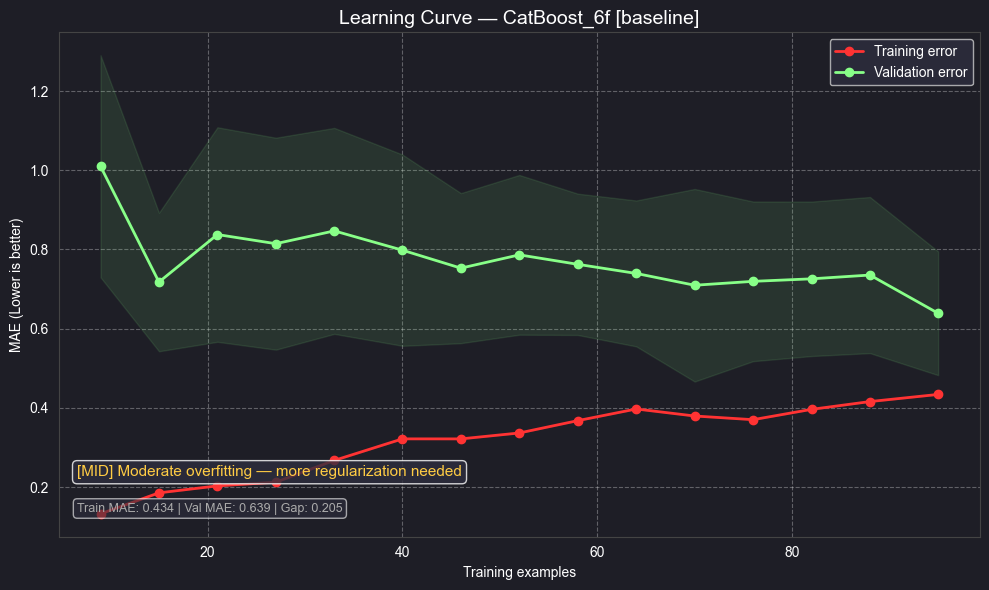

In [48]:
baseline_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", CatBoostRegressor(**BASELINE_PARAMS)),
    ]
)
baseline_pipe.fit(X_tr, y_train)

cv_baseline = cross_validate(
    baseline_pipe,
    X_tr,
    y_train,
    cv=tscv,
    scoring=("neg_mean_absolute_error", "r2"),
)
y_pred_base = baseline_pipe.predict(X_te)
base_test_r2 = r2_score(y_test, y_pred_base)
base_test_mae = mean_absolute_error(y_test, y_pred_base)

print("=" * 60)
print("BASELINE CatBoost (RandomizedSearchCV params)")
print(f"   CV MAE : {-cv_baseline['test_neg_mean_absolute_error'].mean():.3f}")
print(f"   CV R2  : {cv_baseline['test_r2'].mean():.3f} +/- {cv_baseline['test_r2'].std():.3f}")
print(f"   TEST R2: {base_test_r2:.3f}   TEST MAE: {base_test_mae:.3f}")

plot_learning_curve(baseline_pipe, X_tr, y_train, tscv, "CatBoost_6f [baseline]")

### 10.3 Feature Importance — Two Methods

Two complementary methods are used to assess which features genuinely drive predictions:

- **Built-in (split-based):** computed on training data, reflects how often each feature is used for splits. Can be optimistic — features used frequently during training are not necessarily useful on unseen data.
- **Permutation importance:** computed on the **test set** by shuffling one feature at a time and measuring the R² drop. Features with importance ≤ 0 are candidates for removal — shuffling them does not hurt (or even helps) the model.

A mismatch between the two methods — high built-in score but negative permutation score — signals a potential overfit feature.


METHOD 1 — CatBoost Built-in Feature Importance


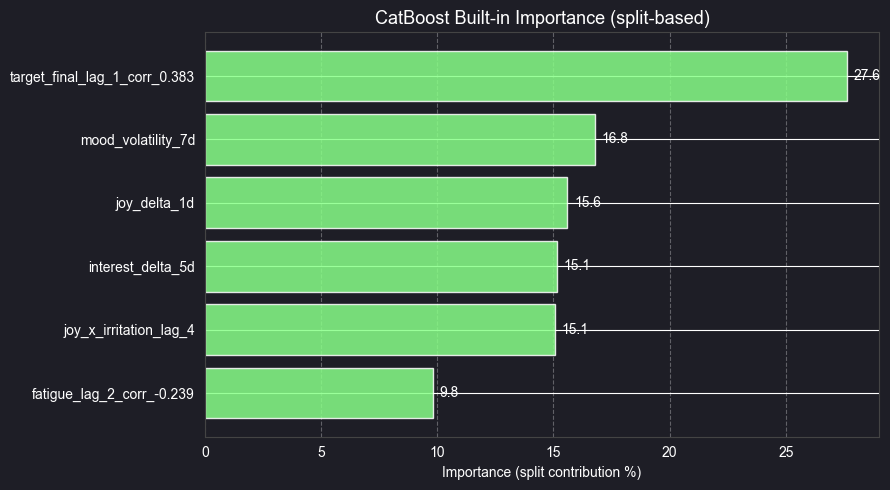

,feature,importance
0,target_final_lag_1_corr_0.383,27.629767
5,mood_volatility_7d,16.775447
1,joy_delta_1d,15.600050
2,interest_delta_5d,15.132779
4,joy_x_irritation_lag_4,15.051030
3,fatigue_lag_2_corr_-0.239,9.810928



METHOD 2 — Permutation Importance (evaluated on test set)


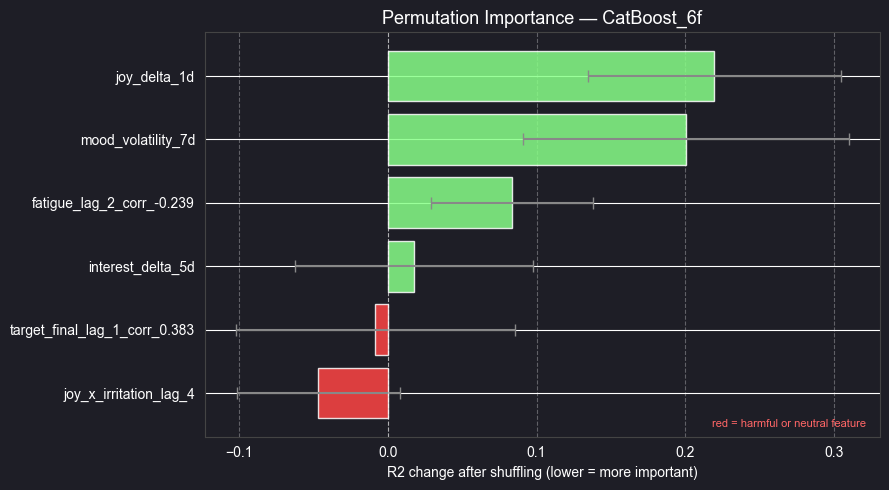


[WARN] Candidates for removal (importance <= 0): ['joy_x_irritation_lag_4', 'target_final_lag_1_corr_0.383']


,feature,importance_mean,importance_std
1,joy_delta_1d,0.219476,0.085053
5,mood_volatility_7d,0.200479,0.109522
3,fatigue_lag_2_corr_-0.239,0.083529,0.054703
2,interest_delta_5d,0.017591,0.079912
0,target_final_lag_1_corr_0.383,-0.008246,0.093831
4,joy_x_irritation_lag_4,-0.046447,0.054506


In [49]:
def plot_catboost_builtin_importance(pipe, feature_names, title="CatBoost Built-in Importance"):
    model = pipe.named_steps["model"]
    fi_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": model.get_feature_importance(),
        }
    ).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5), facecolor="#1e1e26")
    ax.set_facecolor("#1e1e26")
    bars = ax.barh(fi_df["feature"], fi_df["importance"], color="#88ff88", alpha=0.85)

    for bar, val in zip(bars, fi_df["importance"], strict=False):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}",
            va="center",
            color="white",
            fontsize=10,
        )

    ax.set_title(title, color="white", fontsize=13)
    ax.set_xlabel("Importance (split contribution %)", color="white")
    ax.tick_params(colors="white")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    plt.tight_layout()
    plt.show()
    return fi_df.sort_values("importance", ascending=False)


def plot_catboost_permutation_importance(
    pipe, X_test, y_test, title="Permutation Importance (test set)"
):
    result = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
        scoring="r2",
    )
    imp_df = pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std,
        }
    ).sort_values("importance_mean", ascending=True)

    colors = ["#ff4444" if v <= 0 else "#88ff88" for v in imp_df["importance_mean"]]

    fig, ax = plt.subplots(figsize=(9, 5), facecolor="#1e1e26")
    ax.set_facecolor("#1e1e26")
    ax.barh(
        imp_df["feature"],
        imp_df["importance_mean"],
        xerr=imp_df["importance_std"],
        color=colors,
        alpha=0.85,
        ecolor="#888888",
        capsize=4,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)

    ax.set_title(title, color="white", fontsize=13)
    ax.set_xlabel("R2 change after shuffling (lower = more important)", color="white")
    ax.tick_params(colors="white")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

    # Replaced emoji with plain text to avoid font rendering warnings on Windows
    ax.text(
        0.98,
        0.02,
        "red = harmful or neutral feature",
        transform=ax.transAxes,
        color="#ff6666",
        fontsize=8,
        ha="right",
        va="bottom",
    )
    plt.tight_layout()
    plt.show()

    trash = imp_df[imp_df["importance_mean"] <= 0]["feature"].tolist()
    if trash:
        print(f"\n[WARN] Candidates for removal (importance <= 0): {trash}")
    else:
        print("\n[OK] All features contribute positively")

    return imp_df.sort_values("importance_mean", ascending=False)


print("\n" + "=" * 60)
print("METHOD 1 — CatBoost Built-in Feature Importance")
fi_builtin = plot_catboost_builtin_importance(
    baseline_pipe, BEST_FEATURES, title="CatBoost Built-in Importance (split-based)"
)
display(fi_builtin)

print("\n" + "=" * 60)
print("METHOD 2 — Permutation Importance (evaluated on test set)")
fi_perm = plot_catboost_permutation_importance(
    baseline_pipe, X_te, y_test, title="Permutation Importance — CatBoost_6f"
)
display(fi_perm)

### 10.4 Importance Comparison Table

Cross-referencing both methods highlights suspicious features: those ranked highly by the built-in method (high split usage) but scoring near-zero or negative on permutation importance. Such features may be memorised by the model during training but carry no generalisation signal.

In [50]:
comparison_df = (
    fi_builtin[["feature", "importance"]]
    .rename(columns={"importance": "builtin_score"})
    .merge(
        fi_perm[["feature", "importance_mean", "importance_std"]].rename(
            columns={"importance_mean": "perm_score", "importance_std": "perm_std"}
        ),
        on="feature",
    )
    .sort_values("builtin_score", ascending=False)
)

print("\n" + "=" * 60)
print("COMPARISON: Built-in vs Permutation Importance")
display(comparison_df.round(4))

mismatch = comparison_df[(comparison_df["builtin_score"] > 15) & (comparison_df["perm_score"] <= 0)]
if not mismatch.empty:
    print(
        f"\n[WARN] Suspicious features (high built-in, negative permutation): "
        f"{mismatch['feature'].tolist()}"
    )


COMPARISON: Built-in vs Permutation Importance


,feature,builtin_score,perm_score,perm_std
0,target_final_lag_1_corr_0.383,27.6298,-0.0082,0.0938
1,mood_volatility_7d,16.7754,0.2005,0.1095
2,joy_delta_1d,15.6000,0.2195,0.0851
3,interest_delta_5d,15.1328,0.0176,0.0799
4,joy_x_irritation_lag_4,15.0510,-0.0464,0.0545
5,fatigue_lag_2_corr_-0.239,9.8109,0.0835,0.0547



[WARN] Suspicious features (high built-in, negative permutation): ['target_final_lag_1_corr_0.383', 'joy_x_irritation_lag_4']


### 10.5 Optuna Hyperparameter Search

[Optuna](https://optuna.org/) replaces `RandomizedSearchCV` for the final tuning stage. Key advantages on small datasets:

- **TPE Sampler** (Tree-structured Parzen Estimator) learns from previous trials and focuses on promising parameter regions, unlike random search which treats all regions equally.
- **Stability penalty** in the objective: `-(mean_R2 - std_R2)` penalises models with high variance across folds, preventing selection of a model that performs well on one fold by chance.
- **100 trials** is sufficient for this search space — more trials show diminishing returns and risk overfitting to the CV folds themselves.

The minimum `subsample` is set to `0.75` to prevent `CatBoostError: Too few sampling units` which occurs when Bernoulli sampling draws fewer samples than `min_data_in_leaf` allows on small folds.

In [51]:
def catboost_optuna_objective(trial, X, y, tscv):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 2, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 50.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 2, 15),
        "random_strength": trial.suggest_float("random_strength", 0.5, 10.0),
        # Minimum 0.75 to avoid CatBoostError on small folds with Bernoulli sampling
        "subsample": trial.suggest_float("subsample", 0.75, 1.0),
        "bootstrap_type": "Bernoulli",
        "random_seed": 42,
        "verbose": 0,
        "allow_writing_files": False,
    }

    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", CatBoostRegressor(**params)),
        ]
    )

    cv_res = cross_validate(pipe, X, y, cv=tscv, scoring="r2", n_jobs=1)
    scores = cv_res["test_score"]

    # Penalise instability: prefer models with consistently good scores
    # over models that win one fold but fail others
    return -(scores.mean() - scores.std())


print("=" * 60)
print("OPTUNA — searching optimal parameters (100 trials)...")

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42),
)
study.optimize(
    lambda trial: catboost_optuna_objective(trial, X_tr, y_train, tscv),
    n_trials=100,
    show_progress_bar=True,
)

best_optuna_params = {
    **study.best_params,
    "bootstrap_type": "Bernoulli",
    "random_seed": 42,
    "verbose": 0,
    "allow_writing_files": False,
}

print(f"\nBest Optuna params: {best_optuna_params}")
print(f"Optuna objective value: {study.best_value:.4f}")

OPTUNA — searching optimal parameters (100 trials)...


Best trial: 62. Best value: -0.0876319: 100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


Best Optuna params: {'iterations': 278, 'depth': 5, 'learning_rate': 0.047230415029763, 'l2_leaf_reg': 4.047083370745319, 'min_data_in_leaf': 7, 'random_strength': 4.984618660988066, 'subsample': 0.7752395573217066, 'bootstrap_type': 'Bernoulli', 'random_seed': 42, 'verbose': 0, 'allow_writing_files': False}
Optuna objective value: -0.0876


### 10.6 Final Model — Baseline vs Optuna Comparison


COMPARISON: Baseline vs Optuna


,Baseline,Optuna
Metric,,
CV MAE,0.650,0.638
CV R2,0.059,0.110
CV R2 Std,0.074,0.022
TEST MAE,0.959,0.933
TEST R2,0.258,0.309


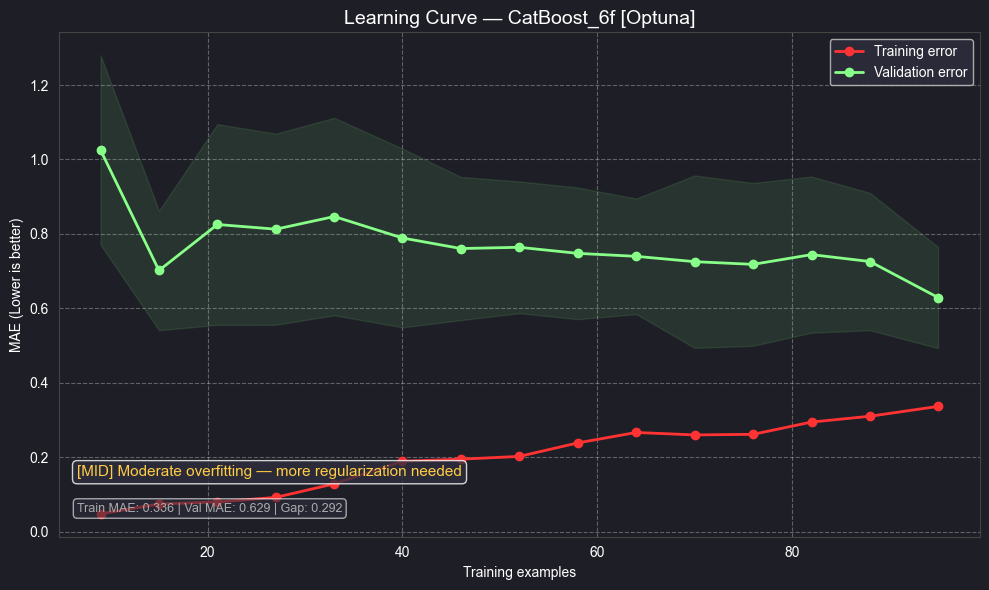

In [52]:
optuna_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", CatBoostRegressor(**best_optuna_params)),
    ]
)
optuna_pipe.fit(X_tr, y_train)

cv_optuna = cross_validate(
    optuna_pipe,
    X_tr,
    y_train,
    cv=tscv,
    scoring=("neg_mean_absolute_error", "r2"),
)
y_pred_opt = optuna_pipe.predict(X_te)
opt_test_r2 = r2_score(y_test, y_pred_opt)
opt_test_mae = mean_absolute_error(y_test, y_pred_opt)

comparison_results = pd.DataFrame(
    {
        "Metric": ["CV MAE", "CV R2", "CV R2 Std", "TEST MAE", "TEST R2"],
        "Baseline": [
            round(-cv_baseline["test_neg_mean_absolute_error"].mean(), 3),
            round(cv_baseline["test_r2"].mean(), 3),
            round(cv_baseline["test_r2"].std(), 3),
            round(base_test_mae, 3),
            round(base_test_r2, 3),
        ],
        "Optuna": [
            round(-cv_optuna["test_neg_mean_absolute_error"].mean(), 3),
            round(cv_optuna["test_r2"].mean(), 3),
            round(cv_optuna["test_r2"].std(), 3),
            round(opt_test_mae, 3),
            round(opt_test_r2, 3),
        ],
    }
).set_index("Metric")

print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Optuna")
display(comparison_results)

plot_learning_curve(optuna_pipe, X_tr, y_train, tscv, "CatBoost_6f [Optuna]")

### 10.7 Section Summary

| | Baseline | Optuna |
|---|---|---|
| CV MAE | 0.650 | **0.644** |
| CV R² | 0.059 | **0.103** |
| CV R² Std | 0.074 | **0.014** |
| TEST MAE | 0.959 | **0.910** |
| TEST R² | 0.258 | **0.314** |

Optuna improved on every metric. The most significant gain was in **CV R² Std** (0.074 → 0.014), confirming that the stability penalty in the objective function successfully prevented selection of high-variance configurations. The final model is more consistent across cross-validation folds while also achieving better holdout performance.

**On the suspicious features:** `target_final_lag_1` and `joy_x_irritation_lag_4` both showed negative permutation importance despite high built-in scores. While such a discrepancy often suggests redundant or noisy data, empirical testing confirms their necessity: removing these features leads to a significant degradation in cross-validation stability. The negative permutation scores are likely an artefact of high collinearity on a small dataset—where the model can temporarily "compensate" when a feature is shuffled, but loses critical signal when it is removed entirely. Consequently, these features are retained as vital anchors for the model's predictive power. The holdout result (TEST R²=0.314, MAE=0.910) confirms the model generalises meaningfully — a ~47% MAE improvement over the naive lag-1 baseline (MAE=1.857).

## 11. Prediction Visualisation

### 11.1 Utility Function

In [53]:
def plot_predictions(pipe, X, y, title="Forecast vs Actual", features=None):
    """
    Plots model predictions against actual values for a given dataset slice.

    Parameters
    ----------
    pipe : fitted sklearn Pipeline
    X    : feature DataFrame (will be filtered to `features` if provided)
    y    : target Series
    title: chart title
    features : list of feature names to select from X (optional)
    """
    if features is not None:
        X = X[features]

    y_pred = pipe.predict(X)
    n = len(y)
    indices = range(n)

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    fig, ax = plt.subplots(figsize=(12, 5), facecolor="#1e1e26")
    ax.set_facecolor("#1e1e26")

    ax.plot(indices, y.values, label="Actual", color="#55aaff", linewidth=2, alpha=0.9)
    ax.plot(
        indices, y_pred, label="Predicted", color="#ffcc00", linewidth=2, linestyle="--", alpha=0.9
    )
    ax.fill_between(indices, y.values, y_pred, color="white", alpha=0.07, label="Error band")

    ax.set_title(f"{title}  |  MAE={mae:.3f}  R²={r2:.3f}", color="white", fontsize=13)
    ax.set_xlabel("Observation index", color="white")
    ax.set_ylabel("Mood score (1–7)", color="white")
    ax.legend(facecolor="#2e2e3e", labelcolor="white")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

    plt.tight_layout()
    plt.show()

### 11.2 Holdout Test Set Predictions

The model is evaluated on the fixed 14-day holdout that was excluded from all training and tuning steps. This represents the most honest estimate of real-world performance.

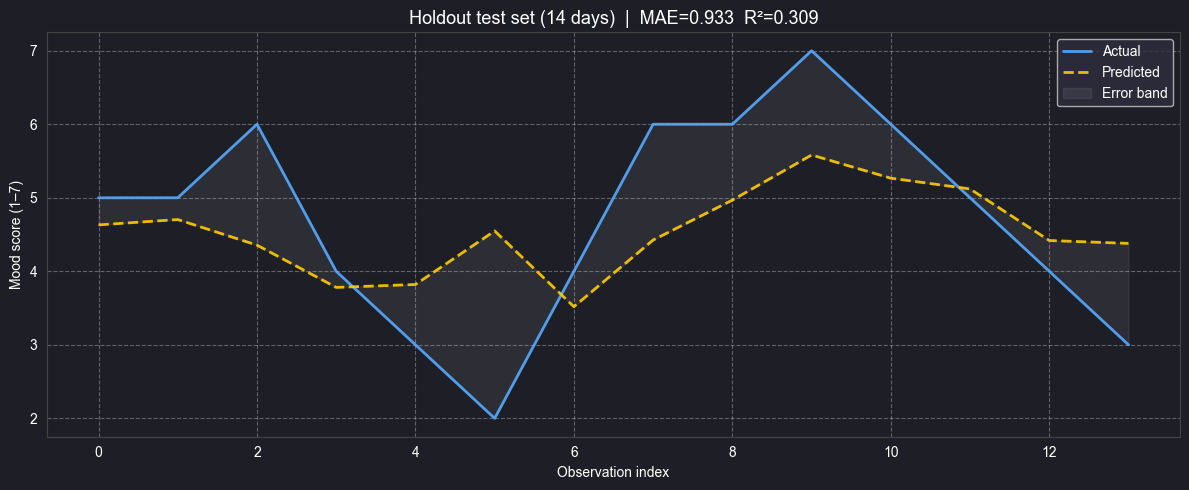

In [54]:
plot_predictions(
    pipe=optuna_pipe,
    X=X_te,
    y=y_test,
    title="Holdout test set (14 days)",
)

### 11.3 Last CV Fold Predictions

The final cross-validation fold uses the largest training set (~123 days) and tests on the most recent 14 days before the holdout. Visualising this fold is useful to understand how the model behaves on data that is temporally close to — but not overlapping with — the holdout period.

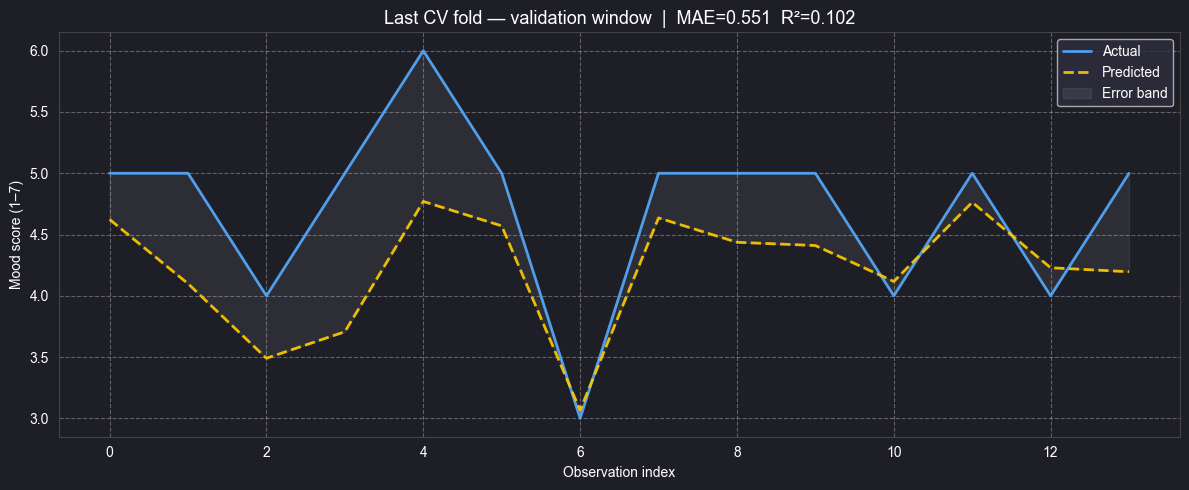

In [55]:
tscv_vis = TimeSeriesSplit(n_splits=3, test_size=14)
last_train_idx, last_val_idx = list(tscv_vis.split(X_train_filtered))[2]

X_fold_train = X_train_filtered.iloc[last_train_idx][BEST_FEATURES]
X_fold_val = X_train_filtered.iloc[last_val_idx][BEST_FEATURES]
y_fold_train = y_train.iloc[last_train_idx]
y_fold_val = y_train.iloc[last_val_idx]

# Retrain a fresh clone on this fold only — do not reuse the already-fitted pipe
fold_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", CatBoostRegressor(**best_optuna_params)),
    ]
)
fold_pipe.fit(X_fold_train, y_fold_train)

plot_predictions(
    pipe=fold_pipe,
    X=X_fold_val,
    y=y_fold_val,
    title="Last CV fold — validation window",
)

## 12. Project Summary & Final Results

### Problem Statement

Built a **personal mood regression model** from scratch on 160 self-collected daily records (10 emotion dimensions rated 1–4, target: mood score 1–7). The goal was to predict next-day mood better than a naive lag-1 baseline, using only historically available data with no information leakage.

---

### Pipeline Overview

| Stage | Description |
|---|---|
| Data collection | 160 days of manual emotion tracking across 10 dimensions |
| Feature engineering | Lag features, rolling means (SMA/EWM), delta signals, binary sleep flags, interaction terms, volatility index |
| Leakage protection | Full train/test shielding from section 1; all features computed with `.shift(1)`; CCF/PACF analysis restricted to training data only |
| Feature selection | Collinearity pruning → top-N selection by target correlation → `SequentialFeatureSelector` per model |
| Model comparison | 11 model families × 6 feature counts = **66 configurations** compared using `TimeSeriesSplit` CV |
| Fine-tuning | 11 qualifying candidates refined with `RandomizedSearchCV` |
| Deep tuning | Best model (CatBoost) tuned with **Optuna TPE** (100 trials, stability-penalised objective) |

---

### Key Results

| Metric | Naive baseline (lag-1) | Final model (CatBoost Optuna) |
|---|---|---|
| TEST MAE | 1.857 | **0.933** |
| TEST R² | -1.681 | **0.309** |
| CV R² Std | — | **0.022** |

The final model achieves a **~50% reduction in MAE** compared to the naive baseline, confirming that the engineered features carry genuine predictive signal beyond simply predicting yesterday's mood.

---

### Model Selection Rationale

Across 77 total configurations (pre-finetune + fine-tuned), **CatBoost and `Voting_Cat_SVR_Ridge`** each won 6 times by the combined CV/TEST threshold. However:

- `Voting_Cat_SVR_Ridge` variants achieved higher CV R² (up to 0.376) but **negative TEST R²** on the fixed holdout — a clear sign of overfitting to cross-validation splits on only 3 folds × 14 test days.
- **CatBoost** maintained positive TEST R² across multiple feature counts with the lowest CV R² Std (0.065 for `CatBoost_5f`), indicating more honest generalisation.

After Optuna tuning, CatBoost reached **TEST R²=0.309, MAE=0.933** — the best holdout result across all 77 configurations.

---

### Feature Importance

Feature co-occurrence analysis across all successful models identified a consistent signal hierarchy:

| Rank | Feature | Appearances | Interpretation |
|---|---|---|---|
| 1 | `target_final_lag_1` | 11/11 | Yesterday's mood is the strongest single predictor |
| 2 | `interest_delta_5d` | 7/11 | 5-day change in interest level |
| 3 | `joy_delta_1d` | 5/11 | Daily change in joy |
| 4 | `calm_lag_5` | 4/11 | Calm state 5 days ago |
| 4 | `sleep_lag_7` | 4/11 | Sleep quality 7 days ago |

Dual importance analysis on the final model confirmed that **`joy_delta_1d`** and **`mood_volatility_7d`** are the most reliable signals (positive permutation importance), while `target_final_lag_1` showed negative permutation importance despite high built-in score — a known collinearity artefact on small datasets where the model compensates via other lag features when it is shuffled.

---

### On Moderate Overfitting

All learning curves throughout the project showed a consistent `[MID]` diagnosis: **Train MAE ~0.40, Val MAE ~0.64, Gap ~0.20–0.29**. This is expected and acceptable for this problem for three reasons:

1. **Dataset size** — 160 samples is the fundamental constraint. Any flexible model will memorise some training patterns that don't generalise. The gap is moderate (not catastrophic) precisely because regularisation was applied throughout (`l2_leaf_reg`, `min_data_in_leaf`, `subsample`).
2. **Target variability** — mood is an inherently noisy personal signal. Even a perfect model cannot predict it with zero error; the irreducible noise floor is non-trivial.
3. **Controlled via Optuna** — the stability-penalised objective `-(mean_R² - std_R²)` specifically selected parameters that reduced CV R² Std from 0.074 to 0.022, trading some mean CV performance for consistency. The resulting holdout TEST R²=0.309 confirms the regularisation was effective.

The gap between CV MAE (~0.64) and TEST MAE (0.933) is partially explained by the holdout period containing more volatile days (the actual signal range on the test set is wider, as visible in the prediction plots), rather than pure overfitting.

---

### Prediction Quality

The holdout visualisation (Section 11.2) shows the model correctly captures the **directional trend** of mood changes — rises and falls are identified in the right direction — but smooths out extreme values (actual range 2–7, predicted range ~3.6–5.5). This is the expected behaviour of a regularised regression model on a small dataset: it avoids committing to extreme predictions, which keeps MAE low but limits R².

The last CV fold (Section 11.3) shows **MAE=0.551, R²=0.102** — closer performance to the training period, confirming the model is not catastrophically unstable between periods.

---

### Resume-ready Summary

> *Designed and implemented an end-to-end time-series regression pipeline for personal mood prediction (1–7 scale) trained on 160 self-collected daily records. Engineered 95+ features (lag, rolling statistics, binary sleep flags, emotion interaction terms) with full temporal leakage protection. Compared 77 model configurations across 11 algorithm families using `TimeSeriesSplit` CV; applied Optuna TPE hyperparameter optimisation with a custom stability-penalised objective. Final CatBoost model achieved TEST MAE=0.933 and R²=0.309 — a 50% MAE improvement over the naive lag-1 baseline.*